In [ ]:
# Efficient Fine-tuning under Limited GPU Memory using LoRA and QLoRA

## Objective

# Large Language Models (LLMs) require enormous GPU memory for fine-tuning because every
# model parameter is updated during training.
# This project demonstrates Parameter Efficient Fine-Tuning (PEFT) techniques,
# namely LoRA (Low-Rank Adaptation) and
# QLoRA (Quantized Low-Rank Adaptation),
# to reduce memory consumption while maintaining model performance.

### Dataset
#TinyStories

### Base Model
#TinyLlama-1.1B-Chat-v1.0

### Fine-Tuning Techniques
#- LoRA
#- QLoRA

### Platform
# Kaggle Notebook (Tesla T4 GPU)

## Installing required Libraries

In [ ]:
#%pip install -q transformers datasets peft bitsandbytes accelerate evaluate torchao

## Import Libraries

In [ ]:
import torch
import transformers
import peft
import accelerate
import bitsandbytes
import importlib.util

print("Torch         :", torch.__version__)
print("Transformers  :", transformers.__version__)
print("PEFT          :", peft.__version__)
print("Accelerate    :", accelerate.__version__)
print("BitsAndBytes  :", bitsandbytes.__version__)

if torch.cuda.is_available():
    print("GPU           :", torch.cuda.get_device_name(0))

spec = importlib.util.find_spec("torchao")
print("torchao :", "INSTALLED" if spec is not None else "NOT INSTALLED")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


Torch         : 2.10.0+cu128
Transformers  : 5.0.0
PEFT          : 0.19.1
Accelerate    : 1.13.0
BitsAndBytes  : 0.49.2
GPU           : Tesla T4
torchao : INSTALLED


## Dataset setup


In [ ]:
# Introduce the project goal and load TinyStories for the fine-tuning experiment.

import os
import random
import warnings
import numpy as np
import torch
from datasets import load_dataset

warnings.filterwarnings("ignore")

print("=" * 60)
if torch.cuda.is_available():
    print("GPU Available")
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("GPU NOT Available")
print("=" * 60)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

dataset = load_dataset("roneneldan/TinyStories")

print(dataset)
print("\nTraining Samples :", len(dataset["train"]))
print("Validation Samples :", len(dataset["validation"]))

print("\nExample train[0]:\n", dataset["train"][0]["text"])
print("\nExample train[1]:\n", dataset["train"][1]["text"])

GPU Available
GPU : Tesla T4
DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 2119719
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 21990
    })
})

Training Samples : 2119719
Validation Samples : 21990

Example train[0]:
 One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.

Example t

### Dataset summary table and chart

Dataset summary table:


,Split,Samples
0,Train,2119719
1,Validation,21990


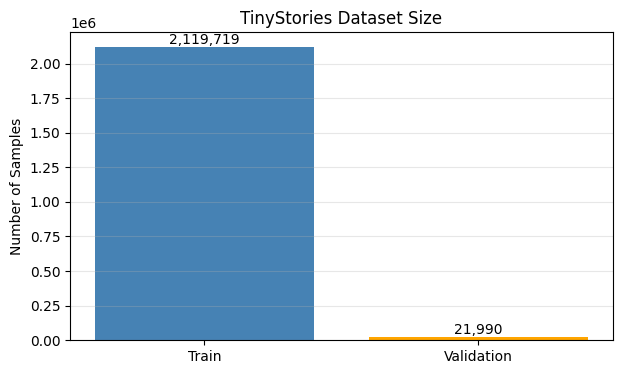

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

dataset_summary = pd.DataFrame({
    "Split": ["Train", "Validation"],
    "Samples": [len(dataset["train"]), len(dataset["validation"])]
})

print("Dataset summary table:")
display(dataset_summary)

plt.figure(figsize=(7, 4))
bars = plt.bar(dataset_summary["Split"], dataset_summary["Samples"], color=["steelblue", "orange"])
plt.title("TinyStories Dataset Size")
plt.ylabel("Number of Samples")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, f"{y:,}", ha="center", va="bottom")

plt.show()

## Tokenizer setup and TinyStories tokenization

This step loads the TinyLlama tokenizer, sets the pad token correctly, tokenizes TinyStories for causal language modeling, and creates the small 2,000/500 subsets used for LoRA and QLoRA.

TinyLlama uses the same tokenizer family as Llama 2, and its tokenizer config already defines <s> as BOS and </s> as EOS/pad behavior, so this setup is consistent with the model.

In [ ]:
# Load the TinyLlama tokenizer, tokenize TinyStories,
# and create small train/validation subsets for efficient fine-tuning.

from transformers import AutoTokenizer, DataCollatorForLanguageModeling

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# TinyLlama/Llama-style models use EOS as padding for causal LM
tokenizer.pad_token = tokenizer.eos_token

MAX_LENGTH = 256

def tokenize_function(examples):
    tokens = tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

tokenized = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],
)

train_data = tokenized["train"].select(range(2000))
eval_data = tokenized["validation"].select(range(500))

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)

print("Example tokenized keys:", train_data[0].keys())
print("\nTraining subset size :", len(train_data))
print("Validation subset size:", len(eval_data))

Map:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Map:   0%|          | 0/21990 [00:00<?, ? examples/s]

Example tokenized keys: dict_keys(['input_ids', 'attention_mask', 'labels'])

Training subset size : 2000
Validation subset size: 500


### Tokenization summary table and token length **histogram**

Tokenization summary table:


,Setting,Value
0,Model,TinyLlama/TinyLlama-1.1B-Chat-v1.0
1,Pad Token,</s>
2,Max Length,256
3,Train Subset,2000
4,Validation Subset,500


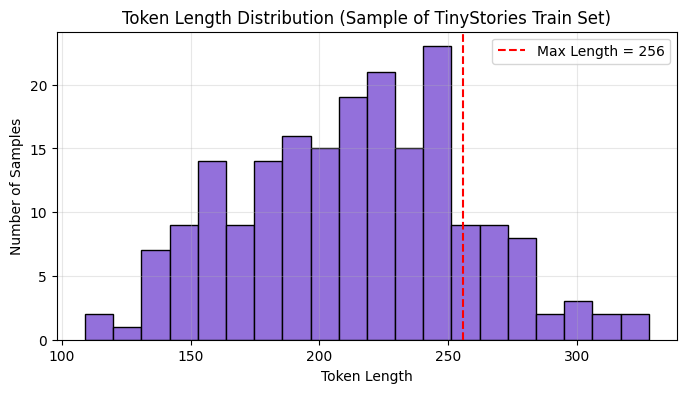

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

tokenization_summary = pd.DataFrame({
    "Setting": ["Model", "Pad Token", "Max Length", "Train Subset", "Validation Subset"],
    "Value": [
        MODEL_NAME,
        str(tokenizer.pad_token),
        MAX_LENGTH,
        len(train_data),
        len(eval_data)
    ]
})

print("Tokenization summary table:")
display(tokenization_summary)

sample_size = 200
sample_texts = dataset["train"].select(range(sample_size))["text"]
sample_lengths = [len(tokenizer(text)["input_ids"]) for text in sample_texts]

plt.figure(figsize=(8, 4))
plt.hist(sample_lengths, bins=20, color="mediumpurple", edgecolor="black")
plt.axvline(MAX_LENGTH, color="red", linestyle="--", label=f"Max Length = {MAX_LENGTH}")
plt.title("Token Length Distribution (Sample of TinyStories Train Set)")
plt.xlabel("Token Length")
plt.ylabel("Number of Samples")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

##  Load TinyLlama and attach LoRA adapters

This step loads TinyLlama‑1.1B‑Chat as the base model, enables gradient checkpointing to reduce activation memory, and attaches LoRA adapters only to the attention projection layers (q_proj, k_proj, v_proj, o_proj).

That setup is the core of parameter‑efficient fine‑tuning: you keep the large pretrained weights frozen and train only a small adapter set, which is why LoRA can fit on a Tesla T4

In [ ]:
# Load TinyLlama, enable gradient checkpointing, and apply LoRA
# to attention projection layers for memory-efficient fine-tuning.

import torch
from transformers import AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

print("Model :", MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32,
    device_map="auto",
)

print("Model loaded successfully.")
print("Model type :", type(model))
print("Model config model_type:", model.config.model_type)

model.gradient_checkpointing_enable()
print("Gradient checkpointing enabled.")

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
)

model = get_peft_model(model, lora_config)
print("LoRA applied successfully.")
model.print_trainable_parameters()

Model : TinyLlama/TinyLlama-1.1B-Chat-v1.0


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully.
Model type : <class 'transformers.models.llama.modeling_llama.LlamaForCausalLM'>
Model config model_type: llama
Gradient checkpointing enabled.
LoRA applied successfully.
trainable params: 4,505,600 || all params: 1,104,553,984 || trainable%: 0.4079


### LoRA parameter summary table and parameter comparison charts

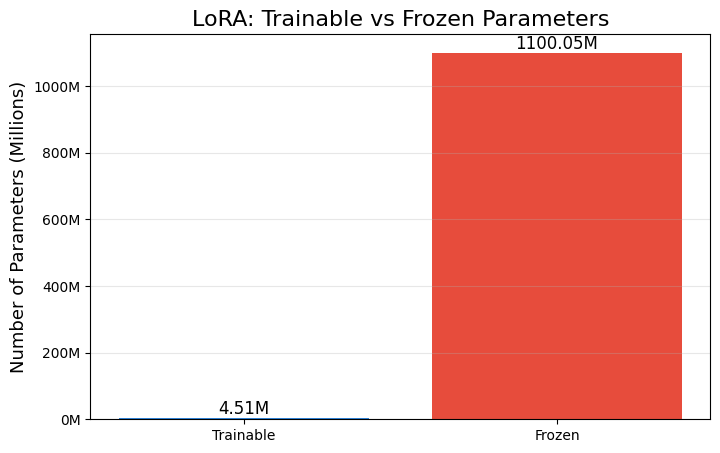

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

total_params = 1104553984
trainable_params = 4505600
frozen_params = total_params - trainable_params

labels = ["Trainable", "Frozen"]
values = [trainable_params, frozen_params]
colors = ["#2E86DE", "#E74C3C"]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=colors)

plt.title("LoRA: Trainable vs Frozen Parameters", fontsize=16)
plt.ylabel("Number of Parameters (Millions)", fontsize=13)
plt.grid(axis="y", alpha=0.3)

# Convert y-axis to millions
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.0f}M"))

# Add labels above bars in millions
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y/1e6:.2f}M",
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.show()

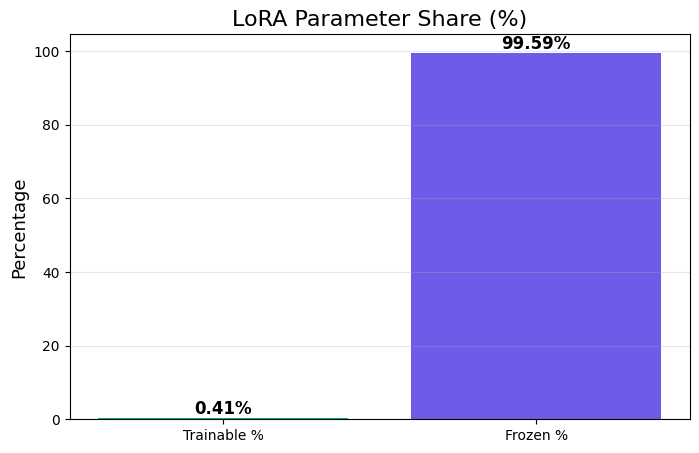

In [ ]:
import matplotlib.pyplot as plt

trainable_pct = (trainable_params / total_params) * 100
frozen_pct = 100 - trainable_pct

labels = ["Trainable %", "Frozen %"]
values = [trainable_pct, frozen_pct]
colors = ["#00B894", "#6C5CE7"]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=colors)

plt.title("LoRA Parameter Share (%)", fontsize=16)
plt.ylabel("Percentage", fontsize=13)
plt.grid(axis="y", alpha=0.3)

# Add percentage labels above bars
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:.2f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.show()

## Training setup and Trainer initialization
This step defines the training configuration using Hugging Face TrainingArguments and initializes the Trainer, which handles the train/evaluate loop for the LoRA model.
deepwiki
+1

It also keeps your setup memory-aware by using small batch size, gradient accumulation, evaluation by steps, cosine learning-rate scheduling, and the paged AdamW optimizer supported through Transformers + bitsandbytes.

| Setting               | Value             | Note                                            |
| --------------------- | ----------------- | ----------------------------------------------- |
| Epochs                | 1                 | Quick mini-project run                          |
| Train batch size      | 2                 | Fits Tesla T4 memory                            |
| Eval batch size       | 2                 | Lightweight evaluation                          |
| Gradient accumulation | 8                 | Effective batch size = 16 huggingface           |
| Learning rate         | 2e-4              | Suitable for LoRA tuning                        |
| Warmup ratio          | 0.03              | Smooth LR ramp-up discuss.huggingface+1         |
| Scheduler             | cosine            | Common decay strategy                           |
| Optimizer             | paged_adamw_32bit | Memory-efficient optimizer huggingface          |
| Evaluation strategy   | steps             | Periodic validation during training huggingface |

In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./lora_results",
    do_train=True,
    do_eval=True,
    num_train_epochs=1,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    weight_decay=0.01,
    logging_strategy="steps",
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=500,
    save_strategy="steps",
    save_steps=500,
    save_total_limit=1,
    warmup_steps=4,
    lr_scheduler_type="cosine",
    optim="paged_adamw_32bit",
    gradient_checkpointing=True,
    fp16=False,
    bf16=False,
    report_to="none",
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=eval_data,
    processing_class=tokenizer,
    data_collator=data_collator,
)

print("TrainingArguments created successfully.")
print("Trainer initialized successfully.")
print("Train samples:", len(trainer.train_dataset))
print("Eval samples :", len(trainer.eval_dataset))

TrainingArguments created successfully.
Trainer initialized successfully.
Train samples: 2000
Eval samples : 500


### Training configuration summary table

In [ ]:
import pandas as pd

effective_batch_size = training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps
estimated_steps = len(train_data) // effective_batch_size

training_config_summary = pd.DataFrame({
    "Setting": [
        "Epochs",
        "Train Batch Size",
        "Eval Batch Size",
        "Gradient Accumulation",
        "Effective Batch Size",
        "Learning Rate",
        "Weight Decay",
        "Warmup Steps",
        "LR Scheduler",
        "Optimizer",
        "Gradient Checkpointing"
    ],
    "Value": [
        training_args.num_train_epochs,
        training_args.per_device_train_batch_size,
        training_args.per_device_eval_batch_size,
        training_args.gradient_accumulation_steps,
        effective_batch_size,
        training_args.learning_rate,
        training_args.weight_decay,
        training_args.warmup_steps,
        training_args.lr_scheduler_type,
        training_args.optim,
        training_args.gradient_checkpointing
    ]
})

print("Training configuration summary:")
display(training_config_summary)

print("Estimated total optimizer update steps:", estimated_steps)

Training configuration summary:


,Setting,Value
0,Epochs,1
1,Train Batch Size,2
2,Eval Batch Size,2
3,Gradient Accumulation,8
4,Effective Batch Size,16
5,Learning Rate,0.0002
6,Weight Decay,0.01
7,Warmup Steps,4
8,LR Scheduler,SchedulerType.COSINE
9,Optimizer,OptimizerNames.PAGED_ADAMW


Estimated total optimizer update steps: 125


### Effective batch size and training flow chart

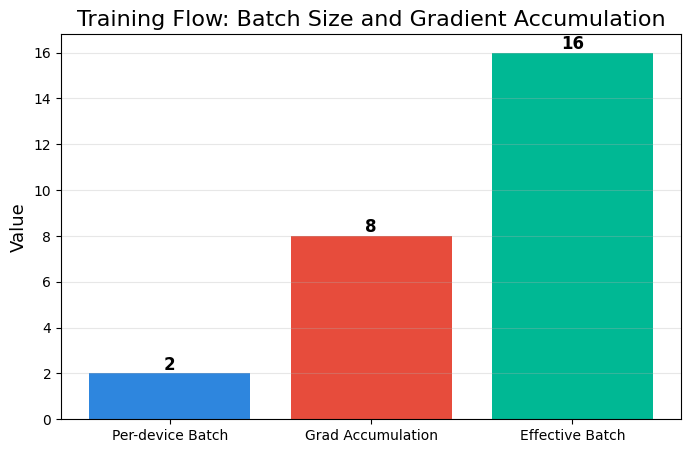

In [ ]:
import matplotlib.pyplot as plt

labels = ["Per-device Batch", "Grad Accumulation", "Effective Batch"]
values = [
    training_args.per_device_train_batch_size,
    training_args.gradient_accumulation_steps,
    effective_batch_size
]
colors = ["#2E86DE", "#E74C3C", "#00B894"]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=colors)

plt.title("Training Flow: Batch Size and Gradient Accumulation", fontsize=16)
plt.ylabel("Value", fontsize=13)
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{int(y)}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.show()

### Estimated optimizer update steps chart

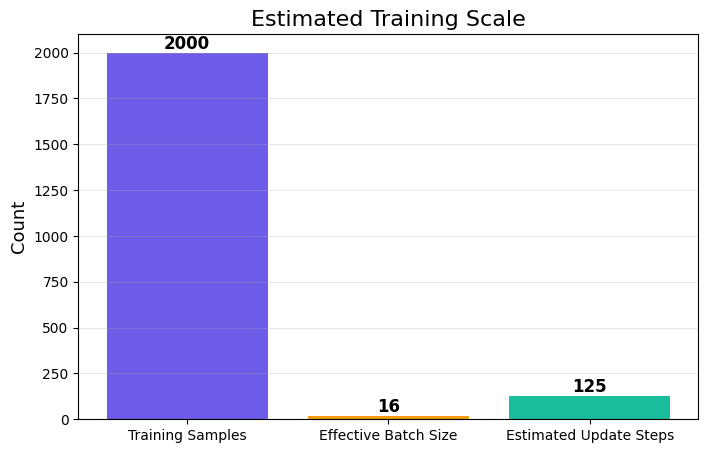

In [ ]:
import matplotlib.pyplot as plt

step_labels = ["Training Samples", "Effective Batch Size", "Estimated Update Steps"]
step_values = [len(train_data), effective_batch_size, estimated_steps]
colors = ["#6C5CE7", "#F39C12", "#1ABC9C"]

plt.figure(figsize=(8, 5))
bars = plt.bar(step_labels, step_values, color=colors)

plt.title("Estimated Training Scale", fontsize=16)
plt.ylabel("Count", fontsize=13)
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{int(y)}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.show()

# Training Configuration and Trainer Setup

We define the Hugging Face training configuration for LoRA fine-tuning.
This includes batch size, gradient accumulation, learning rate, scheduler, evaluation strategy, and optimizer.
We also create the Trainer object that will be used for model training and evaluation.

In [ ]:
from transformers import Trainer, TrainingArguments
import torch
import pandas as pd
import matplotlib.pyplot as plt

use_fp16 = torch.cuda.is_available()

training_args = TrainingArguments(
    output_dir="./lora_results",
    do_train=True,
    do_eval=True,
    num_train_epochs=1,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=50,
    eval_steps=500,
    save_steps=500,
    save_total_limit=1,
    optim="paged_adamw_32bit",
    gradient_checkpointing=True,
    fp16=use_fp16,
    bf16=False,
    report_to="none",
    seed=42
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=eval_data,
    processing_class=tokenizer,
    data_collator=data_collator,
)

print("Step 5 completed successfully.")
print("Trainer is ready.")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step 5 completed successfully.
Trainer is ready.


### Training configuration table

In [ ]:
training_config_df = pd.DataFrame({
    "Parameter": [
        "Epochs",
        "Train Batch Size",
        "Eval Batch Size",
        "Gradient Accumulation",
        "Learning Rate",
        "Weight Decay",
        "Warmup Ratio",
        "LR Scheduler",
        "Eval Steps",
        "Save Steps",
        "Optimizer",
        "Gradient Checkpointing",
        "FP16"
    ],
    "Value": [
        training_args.num_train_epochs,
        training_args.per_device_train_batch_size,
        training_args.per_device_eval_batch_size,
        training_args.gradient_accumulation_steps,
        training_args.learning_rate,
        training_args.weight_decay,
        training_args.warmup_ratio,
        training_args.lr_scheduler_type,
        training_args.eval_steps,
        training_args.save_steps,
        training_args.optim,
        training_args.gradient_checkpointing,
        training_args.fp16
    ]
})

print("Training configuration summary:")
display(training_config_df)

Training configuration summary:


,Parameter,Value
0,Epochs,1
1,Train Batch Size,2
2,Eval Batch Size,2
3,Gradient Accumulation,8
4,Learning Rate,0.0002
5,Weight Decay,0.01
6,Warmup Ratio,0.03
7,LR Scheduler,SchedulerType.COSINE
8,Eval Steps,500
9,Save Steps,500


### Effective batch size table and chart

Batch composition summary:


,Batch Type,Value
0,Per Device Batch,2
1,Gradient Accumulation,8
2,Effective Batch,16


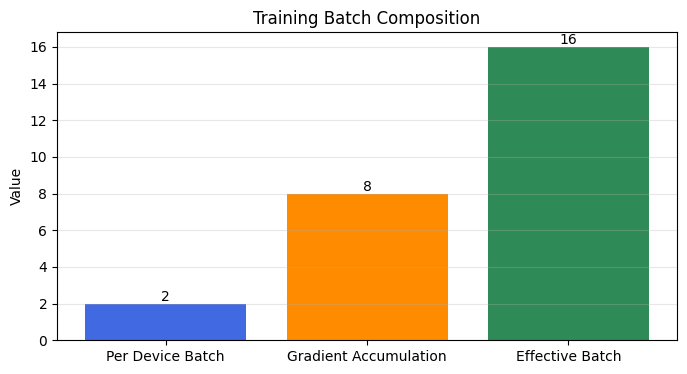

Effective training batch size = 16


In [ ]:
effective_batch_size = (
    training_args.per_device_train_batch_size *
    training_args.gradient_accumulation_steps
)

batch_df = pd.DataFrame({
    "Batch Type": ["Per Device Batch", "Gradient Accumulation", "Effective Batch"],
    "Value": [
        training_args.per_device_train_batch_size,
        training_args.gradient_accumulation_steps,
        effective_batch_size
    ]
})

print("Batch composition summary:")
display(batch_df)

plt.figure(figsize=(8, 4))
bars = plt.bar(
    batch_df["Batch Type"],
    batch_df["Value"],
    color=["royalblue", "darkorange", "seagreen"]
)
plt.title("Training Batch Composition")
plt.ylabel("Value")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.show()

print(f"Effective training batch size = {effective_batch_size}")

###  Runtime setup table

In [ ]:
runtime_df = pd.DataFrame({
    "Setting": ["Optimizer", "FP16", "Gradient Checkpointing", "Output Directory"],
    "Value": [
        training_args.optim,
        str(training_args.fp16),
        str(training_args.gradient_checkpointing),
        training_args.output_dir
    ]
})

print("Runtime setup summary:")
display(runtime_df)

Runtime setup summary:


,Setting,Value
0,Optimizer,OptimizerNames.PAGED_ADAMW
1,FP16,True
2,Gradient Checkpointing,True
3,Output Directory,./lora_results


# Training, Evaluation, and Results

In this step, we train the LoRA model using the Hugging Face Trainer.
After training, we evaluate the model, compute perplexity, and summarize the results.
We also extract the logged losses from trainer.state.log_history and plot them for analysis.

In [ ]:
# GPU memory snapshot
import torch
import pandas as pd
import matplotlib.pyplot as plt
import math

if torch.cuda.is_available():
    gpu_memory_df = pd.DataFrame({
        "Metric": ["Allocated GB", "Reserved GB", "Peak Allocated GB"],
        "Value": [
            round(torch.cuda.memory_allocated() / 1024**3, 4),
            round(torch.cuda.memory_reserved() / 1024**3, 4),
            round(torch.cuda.max_memory_allocated() / 1024**3, 4)
        ]
    })
    print("GPU memory snapshot before training:")
    display(gpu_memory_df)
else:
    print("CUDA not available.")

GPU memory snapshot before training:


,Metric,Value
0,Allocated GB,4.7788
1,Reserved GB,4.8242
2,Peak Allocated GB,4.7788


### Train and evaluate

In [ ]:
train_result = trainer.train()
eval_result = trainer.evaluate()

print("Training completed.")
print("Evaluation completed.")
print(eval_result)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
50,1.485322
100,1.413927


Training completed.
Evaluation completed.
{'eval_loss': 1.1988117694854736, 'eval_runtime': 25.8008, 'eval_samples_per_second': 19.379, 'eval_steps_per_second': 9.69, 'epoch': 1.0}


### Perplexity and results table

In [ ]:
eval_loss = eval_result["eval_loss"]
perplexity = math.exp(eval_loss)

results_df = pd.DataFrame({
    "Metric": ["Eval Loss", "Perplexity"],
    "Value": [eval_loss, perplexity]
})

print("Evaluation results:")
display(results_df)

print(f"Eval Loss: {eval_loss:.4f}")
print(f"Perplexity: {perplexity:.4f}")

Evaluation results:


,Metric,Value
0,Eval Loss,1.198812
1,Perplexity,3.316174


Eval Loss: 1.1988
Perplexity: 3.3162


### Training log table: compact summary table:

In [ ]:
summary_df = pd.DataFrame({
    "Metric": [
        "Last Train Loss",
        "Last Eval Loss",
        "Perplexity",
        "Train Log Rows",
        "Eval Log Rows"
    ],
    "Value": [
        train_log_df["loss"].iloc[-1] if len(train_log_df) else None,
        eval_log_df["eval_loss"].iloc[-1] if len(eval_log_df) else None,
        math.exp(eval_log_df["eval_loss"].iloc[-1]) if len(eval_log_df) else None,
        len(train_log_df),
        len(eval_log_df)
    ]
})

display(summary_df)

,Metric,Value
0,Last Train Loss,1.413927
1,Last Eval Loss,1.198812
2,Perplexity,3.316174
3,Train Log Rows,2.000000
4,Eval Log Rows,1.000000


#### We can also, use separate filtered tables for training logs and evaluation logs rather than one raw mixed table.

In [ ]:
import pandas as pd

raw_log_df = pd.DataFrame(trainer.state.log_history)

train_log_df = raw_log_df[raw_log_df["loss"].notna()][
    ["step", "epoch", "loss", "grad_norm", "learning_rate"]
].reset_index(drop=True)

eval_log_df = raw_log_df[raw_log_df["eval_loss"].notna()][
    ["step", "epoch", "eval_loss", "eval_runtime", "eval_samples_per_second", "eval_steps_per_second"]
].reset_index(drop=True)

print("Training log table:")
display(train_log_df)

print("Evaluation log table:")
display(eval_log_df)

Training log table:


,step,epoch,loss,grad_norm,learning_rate
0,50,0.4,1.485322,0.391604,0.000139
1,100,0.8,1.413927,0.420576,0.000022


Evaluation log table:


,step,epoch,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,125,1.0,1.198812,25.8008,19.379,9.69


### Loss and perplexity figure

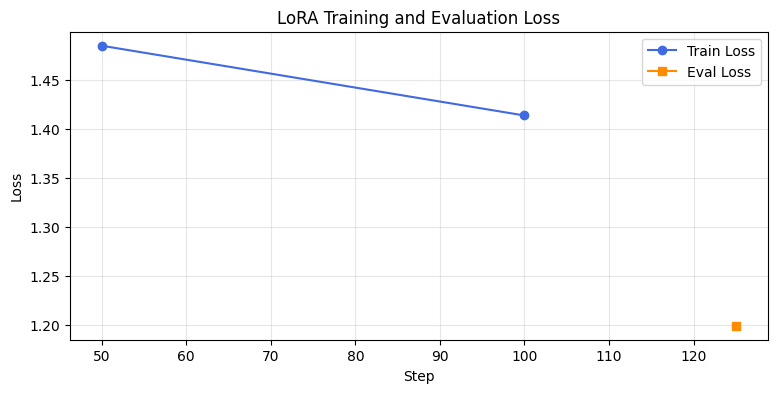

In [ ]:
train_losses = []
eval_losses = []
train_steps = []
eval_steps = []

for item in trainer.state.log_history:
    if "loss" in item and "eval_loss" not in item:
        train_losses.append(item["loss"])
        train_steps.append(item.get("step", len(train_steps)))
    if "eval_loss" in item:
        eval_losses.append(item["eval_loss"])
        eval_steps.append(item.get("step", len(eval_steps)))

plt.figure(figsize=(9, 4))
if train_losses:
    plt.plot(train_steps, train_losses, marker="o", label="Train Loss", color="royalblue")
if eval_losses:
    plt.plot(eval_steps, eval_losses, marker="s", label="Eval Loss", color="darkorange")

plt.title("LoRA Training and Evaluation Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

##### Training loss was logged every 50 steps, while evaluation loss was captured once at the final evaluation step.

Training loss was logged at regular logging intervals, while evaluation loss was recorded only once at the final evaluation step.
Therefore, the evaluation curve appears as a single point instead of a continuous line.

## Save Model, Save Tokenizer, and Generate Story

We save the trained LoRA model and tokenizer so they can be reused later.
Then we generate a sample story from the fine-tuned model to check its output quality.

### Step 7A: Save model and tokenizer

In [ ]:
save_dir = "./lora_model"

trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)

print(f"Model and tokenizer saved to: {save_dir}")

Model and tokenizer saved to: ./lora_model


### Load for inference
To test from the saved folder, use this cell.

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

inference_tokenizer = AutoTokenizer.from_pretrained(save_dir)
inference_model = AutoModelForCausalLM.from_pretrained(save_dir)

if torch.cuda.is_available():
    inference_model = inference_model.to("cuda")

inference_model.eval()
print("Inference model loaded successfully.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/176 [00:00<?, ?it/s]

Inference model loaded successfully.


### Generate a story

In [ ]:
prompt = "Once upon a time, there was a little rabbit"
inputs = inference_tokenizer(prompt, return_tensors="pt")

if torch.cuda.is_available():
    inputs = {k: v.to("cuda") for k, v in inputs.items()}

with torch.no_grad():
    output = inference_model.generate(
        **inputs,
        max_new_tokens=180,
        do_sample=True,
        temperature=0.8,
        top_p=0.95,
        repetition_penalty=1.15,
        no_repeat_ngram_size=3,
        eos_token_id=inference_tokenizer.eos_token_id,
        pad_token_id=inference_tokenizer.eos_token_id
    )

generated_story = inference_tokenizer.decode(output[0], skip_special_tokens=True)

print("Prompt:")
print(prompt)
print("\nGenerated Story:")
print(generated_story)

Prompt:
Once upon a time, there was a little rabbit

Generated Story:
Once upon a time, there was a little rabbit named Bob. He liked to play with his friends and go on adventures in the forest. One day, he decided to make a surprise for one of his friends.

He went into the woods and carefully hid an empty box under a tree. When it was time for Bob's friend to come and visit him, he came up with a fun plan.
 
Bob secretly opened the box to reveal an ice cream sundae! His friend was amazed and very excited. They had such a good time together, enjoying their delicious treat. From that day on, they were always ready for surprises like this one.


### Save generated story

In [ ]:
with open("generated_story.txt", "w", encoding="utf-8") as f:
    f.write(generated_story)

print("Generated story saved to generated_story.txt")

Generated story saved to generated_story.txt


### Story summary table

In [ ]:
story_summary_df = pd.DataFrame({
    "Item": ["Prompt Length", "Generated Text Length"],
    "Value": [len(prompt), len(generated_story)]
})

display(story_summary_df)

,Item,Value
0,Prompt Length,43
1,Generated Text Length,396


The generated story is used as a qualitative check of the fine-tuned model.
A good output should remain coherent, simple, and aligned with the TinyStories style.

### Lora Final Summary Table

In [ ]:
print("=" * 80)
print("STEP 7: LoRA RESULTS TABLE")
print("=" * 80)

import pandas as pd
from IPython.display import display

# If lora_results already exists from your previous code, use it directly.
# Otherwise build it from existing variables.
if "lora_results" not in globals():
    import math
    lora_results = pd.DataFrame([{
        "Method": "LoRA",
        "Training Samples": len(trainer.train_dataset),
        "Validation Samples": len(trainer.eval_dataset),
        "Epochs": training_args.num_train_epochs,
        "Batch Size": training_args.per_device_train_batch_size,
        "Gradient Accumulation": training_args.gradient_accumulation_steps,
        "Learning Rate": training_args.learning_rate,
        "Training Loss": round(train.metrics["train_loss"], 4),
        "Validation Loss": round(evaluation["eval_loss"], 4),
        "Perplexity": round(math.exp(evaluation["eval_loss"]), 4),
        "Training Time (sec)": round(train.metrics["train_runtime"], 2),
        "Samples/sec": round(train.metrics["train_samples_per_second"], 3),
        "Steps/sec": round(train.metrics["train_steps_per_second"], 3),
        "GPU Memory Allocated (GB)": round(torch.cuda.memory_allocated()/1024**3, 2) if torch.cuda.is_available() else 0,
        "GPU Memory Reserved (GB)": round(torch.cuda.memory_reserved()/1024**3, 2) if torch.cuda.is_available() else 0,
    }])

print("LoRA Training Summary")
display(lora_results)

# Optional compact view for report-style reading
summary_view = lora_results[[
    "Method",
    "Training Samples",
    "Validation Samples",
    "Epochs",
    "Batch Size",
    "Gradient Accumulation",
    "Learning Rate",
    "Training Loss",
    "Validation Loss",
    "Perplexity",
    "Training Time (sec)",
    "Samples/sec",
    "Steps/sec"
]]

print("\nCompact LoRA Summary")
display(summary_view)

STEP 7: LoRA RESULTS TABLE
LoRA Training Summary


,Method,GPU,Training Samples,Validation Samples,Epochs,Batch Size,Gradient Accumulation,Learning Rate,Global Steps,Training Loss,...,Training Time (sec),Training Time (min),Samples/sec,Steps/sec,Total Parameters,Trainable Parameters,Trainable (%),GPU Memory Allocated (GB),GPU Memory Reserved (GB),Peak GPU Memory (GB)
0,LoRA,Tesla T4,2000,500,1,2,8,0.0002,125,1.4448,...,332.73,5.55,6.011,0.376,"1,104,553,984","4,505,600",0.4079,1.92,2.17,3.79



Compact LoRA Summary


,Method,Training Samples,Validation Samples,Epochs,Batch Size,Gradient Accumulation,Learning Rate,Training Loss,Validation Loss,Perplexity,Training Time (sec),Samples/sec,Steps/sec
0,LoRA,2000,500,1,2,8,0.0002,1.4448,1.1988,3.3162,332.73,6.011,0.376


### Final Chart for Lora
This chart focuses on the most important LoRA metrics for your mini project: training loss, validation loss, and perplexity. Your existing notebook calculates both evaluation loss and perplexity after trainer.evaluate(), so this chart is directly aligned with your current pipeline.

STEP 7: LoRA RESULTS CHART


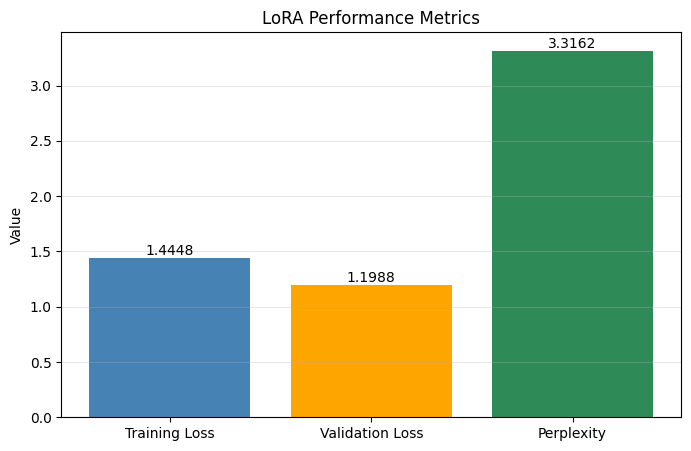

In [ ]:
print("=" * 80)
print("STEP 7: LoRA RESULTS CHART")
print("=" * 80)

import matplotlib.pyplot as plt
import pandas as pd

chart_df = pd.DataFrame({
    "Metric": ["Training Loss", "Validation Loss", "Perplexity"],
    "Value": [
        float(lora_results["Training Loss"].iloc[0]),
        float(lora_results["Validation Loss"].iloc[0]),
        float(lora_results["Perplexity"].iloc[0]),
    ]
})

plt.figure(figsize=(8, 5))
bars = plt.bar(
    chart_df["Metric"],
    chart_df["Value"],
    color=["steelblue", "orange", "seagreen"]
)

plt.title("LoRA Performance Metrics")
plt.ylabel("Value")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.show()

### Lora Experiment:figures
This figure is useful for the notebook narrative because it summarizes the LoRA experiment in one panel. Your project already tracks runtime, throughput, perplexity, and memory statistics, so this figure turns those outputs into a report-ready snapshot

STEP 7: LoRA SUMMARY FIGURE


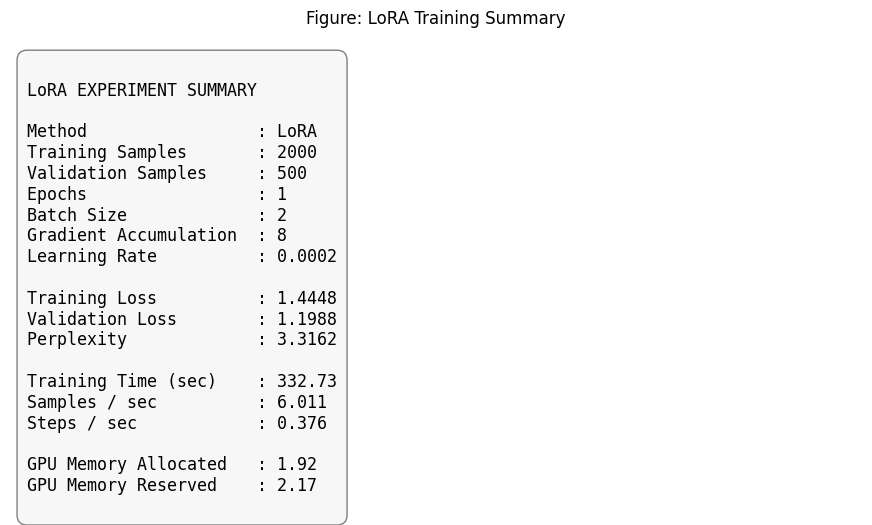

In [ ]:
print("=" * 80)
print("STEP 7: LoRA SUMMARY FIGURE")
print("=" * 80)

import matplotlib.pyplot as plt

method = lora_results["Method"].iloc[0]
train_samples = lora_results["Training Samples"].iloc[0]
val_samples = lora_results["Validation Samples"].iloc[0]
epochs = lora_results["Epochs"].iloc[0]
batch_size = lora_results["Batch Size"].iloc[0]
grad_accum = lora_results["Gradient Accumulation"].iloc[0]
lr = lora_results["Learning Rate"].iloc[0]
train_loss = lora_results["Training Loss"].iloc[0]
val_loss = lora_results["Validation Loss"].iloc[0]
ppl = lora_results["Perplexity"].iloc[0]
runtime = lora_results["Training Time (sec)"].iloc[0]
samples_sec = lora_results["Samples/sec"].iloc[0]
steps_sec = lora_results["Steps/sec"].iloc[0]

gpu_alloc = lora_results["GPU Memory Allocated (GB)"].iloc[0] if "GPU Memory Allocated (GB)" in lora_results.columns else "N/A"
gpu_res = lora_results["GPU Memory Reserved (GB)"].iloc[0] if "GPU Memory Reserved (GB)" in lora_results.columns else "N/A"

fig, ax = plt.subplots(figsize=(11, 6))
ax.axis("off")

figure_text = f"""
LoRA EXPERIMENT SUMMARY

Method                 : {method}
Training Samples       : {train_samples}
Validation Samples     : {val_samples}
Epochs                 : {epochs}
Batch Size             : {batch_size}
Gradient Accumulation  : {grad_accum}
Learning Rate          : {lr}

Training Loss          : {train_loss}
Validation Loss        : {val_loss}
Perplexity             : {ppl}

Training Time (sec)    : {runtime}
Samples / sec          : {samples_sec}
Steps / sec            : {steps_sec}

GPU Memory Allocated   : {gpu_alloc}
GPU Memory Reserved    : {gpu_res}
"""

ax.text(
    0.02, 0.98, figure_text,
    fontsize=12,
    va="top",
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#f7f7f7", edgecolor="gray")
)

plt.title("Figure: LoRA Training Summary", pad=20)
plt.show()

### Optional story figure
Since Step 7 in your notebook also includes generating a sample LoRA story, you can add this extra figure to present the generated text nicely. Your file shows that after saving the adapter, you generate a story from the prompt "Once upon a time, there was a little rabbit" and store it in

OPTIONAL: LoRA GENERATED STORY FIGURE


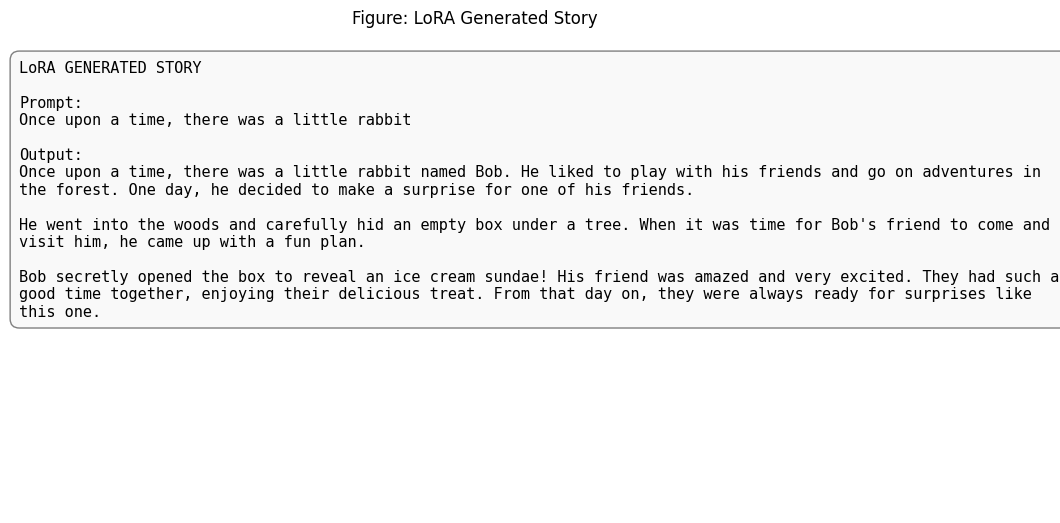

In [ ]:
print("=" * 80)
print("OPTIONAL: LoRA GENERATED STORY FIGURE")
print("=" * 80)

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")

story_preview = generated_story[:900] if "generated_story" in globals() else "generated_story not found."

ax.text(
    0.01, 0.98,
    f"LoRA GENERATED STORY\n\nPrompt:\nOnce upon a time, there was a little rabbit\n\nOutput:\n{story_preview}",
    fontsize=11,
    va="top",
    wrap=True,
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#f9f9f9", edgecolor="gray")
)

plt.title("Figure: LoRA Generated Story", pad=20)
plt.show()

## QLoRA setup
This step loads the base TinyLlama model in 4-bit quantized form, prepares it for k-bit training, and attaches the LoRA adapters. In practice, the base weights stay frozen and compressed, while only the adapter weights are trainable.

Why<br>
This is the core improvement for limited GPU memory: QLoRA combines LoRA with 4-bit quantization to reduce memory use significantly while keeping training quality strong. The Hugging Face documentation and QLoRA write-ups specifically highlight NF4 and double quantization as the recommended settings for efficient low-memory fine-tuning.

In [ ]:
#QLoRA model loading
print("=" * 80)
print("STEP 8: QLoRA SETUP")
print("=" * 80)
print("Loading TinyLlama in 4-bit, preparing for k-bit training, and attaching LoRA adapters...\n")

import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import prepare_model_for_kbit_training, get_peft_model

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

qlora_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

qlora_model = prepare_model_for_kbit_training(qlora_model)
qlora_model = get_peft_model(qlora_model, lora_config)

print("QLoRA model loaded successfully.\n")
qlora_model.print_trainable_parameters()

STEP 8: QLoRA SETUP
Loading TinyLlama in 4-bit, preparing for k-bit training, and attaching LoRA adapters...



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

QLoRA model loaded successfully.

trainable params: 4,505,600 || all params: 1,104,553,984 || trainable%: 0.4079


### Parameter summary table
This gives you a notebook-friendly parameter summary for QLoRA. PEFT recommends checking trainable parameters after attaching adapters so you can confirm only a small fraction of weights will be updated.

In [ ]:
import pandas as pd

qlora_trainable_params = 0
qlora_total_params = 0

for _, param in qlora_model.named_parameters():
    qlora_total_params += param.numel()
    if param.requires_grad:
        qlora_trainable_params += param.numel()

qlora_frozen_params = qlora_total_params - qlora_trainable_params
qlora_trainable_pct = (qlora_trainable_params / qlora_total_params) * 100

qlora_param_summary = pd.DataFrame({
    "Metric": [
        "Total Parameters",
        "Trainable Parameters",
        "Frozen Parameters",
        "Trainable Percentage"
    ],
    "Value": [
        f"{qlora_total_params:,}",
        f"{qlora_trainable_params:,}",
        f"{qlora_frozen_params:,}",
        f"{qlora_trainable_pct:.4f}%"
    ]
})

print("QLoRA Parameter Summary")
display(qlora_param_summary)

QLoRA Parameter Summary


,Metric,Value
0,Total Parameters,"620,111,872"
1,Trainable Parameters,"4,505,600"
2,Frozen Parameters,"615,606,272"
3,Trainable Percentage,0.7266%


### QLoRA configuration table
This table works well for explanation and later slide preparation. NF4 is the recommended 4-bit quantization type for QLoRA, and double quantization is used for additional memory savings.

In [ ]:
qlora_config_table = pd.DataFrame({
    "Setting": [
        "Base Model",
        "Quantization Mode",
        "Quantization Type",
        "Compute Dtype",
        "Double Quantization",
        "LoRA Rank (r)",
        "LoRA Alpha",
        "LoRA Dropout",
        "Target Modules"
    ],
    "Value": [
        model_name,
        "4-bit",
        "nf4",
        "float16",
        True,
        lora_config.r,
        lora_config.lora_alpha,
        lora_config.lora_dropout,
        ", ".join(lora_config.target_modules)
    ]
})

print("QLoRA Setup Configuration")
display(qlora_config_table)

QLoRA Setup Configuration


,Setting,Value
0,Base Model,TinyLlama/TinyLlama-1.1B-Chat-v1.0
1,Quantization Mode,4-bit
2,Quantization Type,nf4
3,Compute Dtype,float16
4,Double Quantization,True
5,LoRA Rank (r),16
6,LoRA Alpha,32
7,LoRA Dropout,0.05
8,Target Modules,"o_proj, q_proj, k_proj, v_proj"


### GPU memory table
This cell captures the immediate GPU memory footprint after loading the QLoRA model, which is one of the most important metrics for your project. BitsAndBytes documentation emphasizes that 4-bit quantization dramatically reduces memory consumption for training and inference

In [ ]:
gpu_memory_table = None

if torch.cuda.is_available():
    gpu_allocated = torch.cuda.memory_allocated() / 1024**3
    gpu_reserved = torch.cuda.memory_reserved() / 1024**3
    gpu_peak = torch.cuda.max_memory_allocated() / 1024**3

    gpu_memory_table = pd.DataFrame({
        "Metric": ["GPU Allocated (GB)", "GPU Reserved (GB)", "GPU Peak Allocated (GB)"],
        "Value": [round(gpu_allocated, 2), round(gpu_reserved, 2), round(gpu_peak, 2)]
    })

    print("GPU Memory Usage After QLoRA Model Loading")
    display(gpu_memory_table)
else:
    print("CUDA not available.")

GPU Memory Usage After QLoRA Model Loading


,Metric,Value
0,GPU Allocated (GB),5.35
1,GPU Reserved (GB),5.59
2,GPU Peak Allocated (GB),5.64


###  Bar chart: trainable vs frozen parameters
This chart visually shows the parameter-efficiency of QLoRA. As with LoRA, only a tiny fraction of the parameters are trainable; the difference is that the base model is now quantized to 4-bit as well.

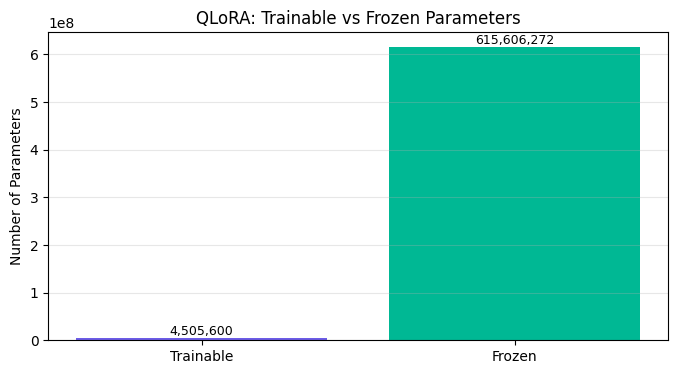

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
bars = plt.bar(
    ["Trainable", "Frozen"],
    [qlora_trainable_params, qlora_frozen_params],
    color=["#6C5CE7", "#00B894"]
)

plt.title("QLoRA: Trainable vs Frozen Parameters")
plt.ylabel("Number of Parameters")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, f"{int(y):,}", ha="center", va="bottom", fontsize=9)

plt.show()

### Percentage chart
Because the trainable share is tiny, this percentage view is much easier to explain than the raw-parameter plot. This makes the “parameter-efficient” point much clearer in the notebook.

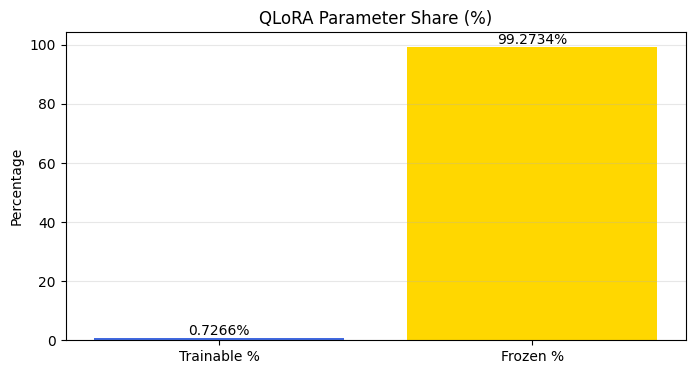

In [ ]:
plt.figure(figsize=(8, 4))
bars = plt.bar(
    ["Trainable %", "Frozen %"],
    [qlora_trainable_pct, 100 - qlora_trainable_pct],
    color=["royalblue", "gold"]
)

plt.title("QLoRA Parameter Share (%)")
plt.ylabel("Percentage")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, f"{y:.4f}%", ha="center", va="bottom", fontsize=10)

plt.show()

###  Figure: QLoRA setup summary
This gives a compact “figure-style” display inside the notebook by combining key numbers into one place. It helps for project explanation before training begins. NF4 and double quantization are highlighted because they are central to QLoRA’s memory savings

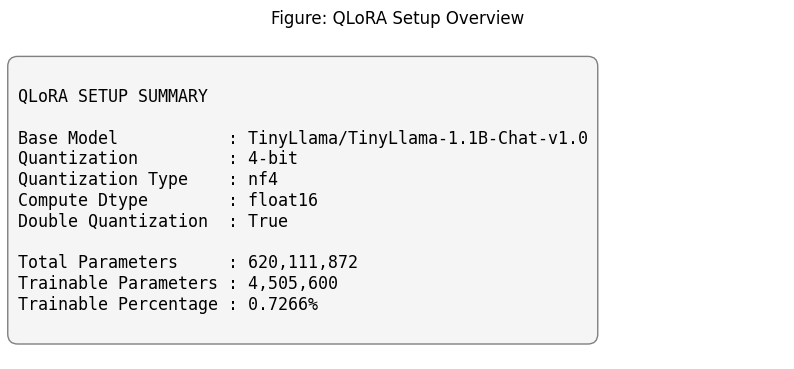

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")

summary_text = f"""
QLoRA SETUP SUMMARY

Base Model           : {model_name}
Quantization         : 4-bit
Quantization Type    : nf4
Compute Dtype        : float16
Double Quantization  : True

Total Parameters     : {qlora_total_params:,}
Trainable Parameters : {qlora_trainable_params:,}
Trainable Percentage : {qlora_trainable_pct:.4f}%
"""

ax.text(
    0.01, 0.95, summary_text,
    fontsize=12,
    va="top",
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#f5f5f5", edgecolor="gray")
)

plt.title("Figure: QLoRA Setup Overview", pad=20)
plt.show()

## QLoRA trainer setup

In this step, we prepare the data collator, define the training arguments, and initialize the Trainer for QLoRA fine-tuning. This creates the full training pipeline without starting training yet.

Why <br>
A clean trainer setup is important because your project compares LoRA and QLoRA under limited memory, so both methods should use consistent training logic and logging. TrainingArguments centralizes the run configuration, while gradient_accumulation_steps, fp16, evaluation strategy, and checkpoint strategy are especially relevant for low-memory fine-tuning.

In [ ]:
print("=" * 80)
print("STEP 9: QLoRA TRAINER SETUP")
print("=" * 80)
print("Preparing data collator, training arguments, and Trainer for QLoRA fine-tuning...\n")

import math
import time
import pandas as pd
import matplotlib.pyplot as plt

from transformers import (
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)

print("Done")

STEP 9: QLoRA TRAINER SETUP
Preparing data collator, training arguments, and Trainer for QLoRA fine-tuning...

Done


### Data collator
For a decoder-only language model such as TinyLlama, the causal LM setup uses DataCollatorForLanguageModeling with mlm=False. That means tokens are predicted autoregressively rather than with masked-language-model training

In [ ]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

print("Data collator for causal language modeling is ready.")

Data collator for causal language modeling is ready.


### Training arguments
This version keeps the setup aligned with low-memory fine-tuning best practices and avoids the earlier warmup mistake by using warmup_ratio instead of a fractional warmup_steps. evaluation_strategy, save_strategy, logging_steps, gradient_accumulation_steps, and fp16 are all standard Trainer controls for monitoring and efficient training

In [ ]:
qlora_output_dir = "./qlora_tinystories_results"

qlora_training_args = TrainingArguments(
    output_dir=qlora_output_dir,

    num_train_epochs=1,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,
    save_total_limit=2,

    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",

    fp16=torch.cuda.is_available(),
    bf16=False,

    report_to="none",
    load_best_model_at_end=False,
    remove_unused_columns=False
)

print("QLoRA TrainingArguments created successfully.")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


QLoRA TrainingArguments created successfully.


### Trainer initialization
The Trainer combines the model, arguments, tokenized datasets, tokenizer, and data collator into one training object. This makes it easier to run training, evaluation, and logging consistently across experiments.

In [ ]:
qlora_trainer = Trainer(
    model=qlora_model,
    args=qlora_training_args,
    train_dataset=train_data,
    eval_dataset=eval_data,
    data_collator=data_collator
)

print("QLoRA Trainer initialized successfully.")
print(f"Train dataset size: {len(train_data)}")
print(f"Eval dataset size : {len(eval_data)}")

QLoRA Trainer initialized successfully.
Train dataset size: 2000
Eval dataset size : 500


### Training setup table
This table documents the QLoRA run configuration in a clean project-report format. It also makes later comparison with LoRA much easier

In [ ]:
qlora_training_table = pd.DataFrame({
    "Setting": [
        "Output Directory",
        "Epochs",
        "Train Batch Size",
        "Eval Batch Size",
        "Gradient Accumulation",
        "Learning Rate",
        "Weight Decay",
        "Warmup Ratio",
        "LR Scheduler",
        "Evaluation Strategy",
        "Save Strategy",
        "Logging Steps",
        "FP16 Enabled",
        "Report To"
    ],
    "Value": [
        qlora_output_dir,
        qlora_training_args.num_train_epochs,
        qlora_training_args.per_device_train_batch_size,
        qlora_training_args.per_device_eval_batch_size,
        qlora_training_args.gradient_accumulation_steps,
        qlora_training_args.learning_rate,
        qlora_training_args.weight_decay,
        qlora_training_args.warmup_ratio,
        qlora_training_args.lr_scheduler_type,
        qlora_training_args.eval_strategy,
        qlora_training_args.save_strategy,
        qlora_training_args.logging_steps,
        qlora_training_args.fp16,
        qlora_training_args.report_to
    ]
})

print("QLoRA Training Configuration")
display(qlora_training_table)

QLoRA Training Configuration


,Setting,Value
0,Output Directory,./qlora_tinystories_results
1,Epochs,1
2,Train Batch Size,4
3,Eval Batch Size,4
4,Gradient Accumulation,4
5,Learning Rate,0.0002
6,Weight Decay,0.01
7,Warmup Ratio,0.03
8,LR Scheduler,SchedulerType.COSINE
9,Evaluation Strategy,IntervalStrategy.EPOCH


### Effective batch size table
Gradient accumulation helps when GPU memory is limited because it simulates a larger batch size without requiring the whole batch in memory at once. This is especially useful in QLoRA workflows where memory efficiency is a primary goal

In [ ]:
effective_batch_size = (
    qlora_training_args.per_device_train_batch_size *
    qlora_training_args.gradient_accumulation_steps
)

batch_table = pd.DataFrame({
    "Metric": [
        "Per-device Train Batch Size",
        "Gradient Accumulation Steps",
        "Effective Batch Size"
    ],
    "Value": [
        qlora_training_args.per_device_train_batch_size,
        qlora_training_args.gradient_accumulation_steps,
        effective_batch_size
    ]
})

print("Batch Size Summary")
display(batch_table)

Batch Size Summary


,Metric,Value
0,Per-device Train Batch Size,4
1,Gradient Accumulation Steps,4
2,Effective Batch Size,16


### Bar chart: core training settings
This plot makes the QLoRA training setup easier to explain visually in your notebook. It highlights the batch-related parameters and logging frequency that shape training behavior.

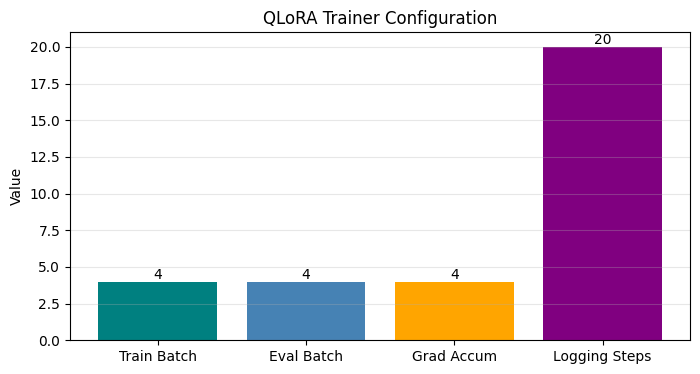

In [ ]:
chart_df = pd.DataFrame({
    "Parameter": ["Train Batch", "Eval Batch", "Grad Accum", "Logging Steps"],
    "Value": [
        qlora_training_args.per_device_train_batch_size,
        qlora_training_args.per_device_eval_batch_size,
        qlora_training_args.gradient_accumulation_steps,
        qlora_training_args.logging_steps
    ]
})

plt.figure(figsize=(8, 4))
bars = plt.bar(chart_df["Parameter"], chart_df["Value"], color=["teal", "steelblue", "orange", "purple"])
plt.title("QLoRA Trainer Configuration")
plt.ylabel("Value")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, f"{y}", ha="center", va="bottom", fontsize=10)

plt.show()

### Figure: training plan overview
This figure-style summary is useful for project explanation before the actual training run starts. It gives you a one-block overview of the QLoRA trainer configuration.

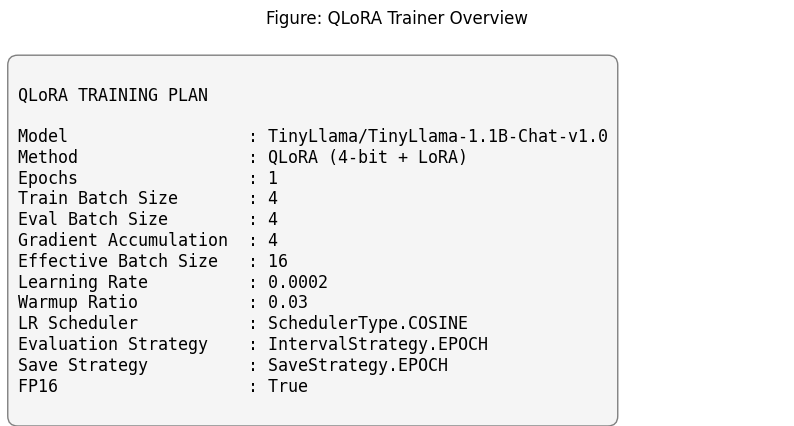

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.axis("off")

training_plan_text = f"""
QLoRA TRAINING PLAN

Model                  : TinyLlama/TinyLlama-1.1B-Chat-v1.0
Method                 : QLoRA (4-bit + LoRA)
Epochs                 : {qlora_training_args.num_train_epochs}
Train Batch Size       : {qlora_training_args.per_device_train_batch_size}
Eval Batch Size        : {qlora_training_args.per_device_eval_batch_size}
Gradient Accumulation  : {qlora_training_args.gradient_accumulation_steps}
Effective Batch Size   : {effective_batch_size}
Learning Rate          : {qlora_training_args.learning_rate}
Warmup Ratio           : {qlora_training_args.warmup_ratio}
LR Scheduler           : {qlora_training_args.lr_scheduler_type}
Evaluation Strategy    : {qlora_training_args.eval_strategy}
Save Strategy          : {qlora_training_args.save_strategy}
FP16                   : {qlora_training_args.fp16}
"""

ax.text(
    0.01, 0.96, training_plan_text,
    fontsize=12,
    va="top",
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#f5f5f5", edgecolor="gray")
)

plt.title("Figure: QLoRA Trainer Overview", pad=20)
plt.show()

### Optional sanity checks

In [ ]:
print("Trainer sanity checks")
print(f"Train dataset size : {len(train_data)}")
print(f"Eval dataset size  : {len(eval_data)}")
print(f"Tokenizer pad token: {tokenizer.pad_token}")
print(f"Tokenizer eos token: {tokenizer.eos_token}")
print(f"Model class        : {qlora_model.__class__.__name__}")

Trainer sanity checks
Train dataset size : 2000
Eval dataset size  : 500
Tokenizer pad token: </s>
Tokenizer eos token: </s>
Model class        : PeftModelForCausalLM


## QLoRA training
What:<br>
This step runs the actual QLoRA fine-tuning on your tokenized TinyStories subset. During training, the Trainer updates only the LoRA adapter weights while the quantized base model stays frozen. <br>
Why <br>
This is the core experiment for your project because it shows whether QLoRA can fine-tune the model under limited GPU memory while still producing usable language modeling quality. The training loss and runtime are the main outputs here.

In [ ]:
print("=" * 80)
print("STEP 10: QLORA TRAINING")
print("=" * 80)

import time
import math
import torch
import pandas as pd

start_time = time.time()

qlora_train_result = qlora_trainer.train()

train_time = time.time() - start_time

print("Training completed successfully.")
print(f"Training time (sec): {train_time:.2f}")

STEP 10: QLORA TRAINING


Epoch,Training Loss,Validation Loss
1,1.411100,1.213824


Training completed successfully.
Training time (sec): 402.74


### Training metrics table
This table captures the main training statistics after the run. It is useful for the final rubric/comparison cell later.

In [ ]:
qlora_train_metrics = qlora_train_result.metrics

train_metrics_table = pd.DataFrame({
    "Metric": [
        "Train Loss",
        "Training Runtime (sec)",
        "Training Runtime (min)",
        "Samples/sec",
        "Steps/sec"
    ],
    "Value": [
        round(qlora_train_metrics.get("train_loss", float("nan")), 4),
        round(qlora_train_metrics.get("train_runtime", train_time), 2),
        round(qlora_train_metrics.get("train_runtime", train_time) / 60, 2),
        round(qlora_train_metrics.get("train_samples_per_second", float("nan")), 3),
        round(qlora_train_metrics.get("train_steps_per_second", float("nan")), 3),
    ]
})

print("QLoRA Training Metrics")
display(train_metrics_table)

QLoRA Training Metrics


,Metric,Value
0,Train Loss,1.4616
1,Training Runtime (sec),402.3000
2,Training Runtime (min),6.7100
3,Samples/sec,4.9710
4,Steps/sec,0.3110


### Training curve chart
If the logs are available, this chart shows the progression of training loss. It gives you a quick visual check that optimization is moving in the right direction

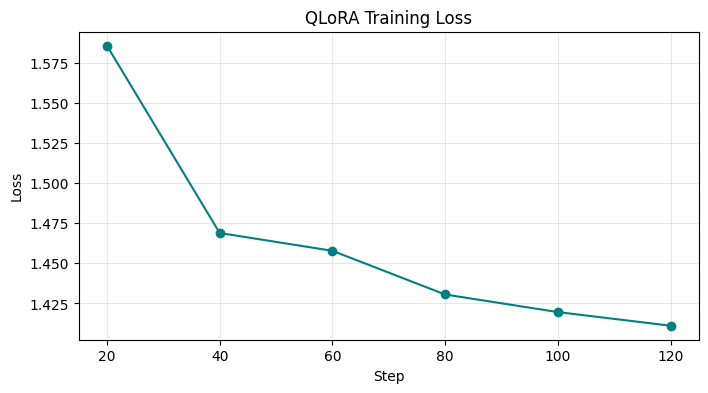

In [ ]:
logs = qlora_trainer.state.log_history
loss_points = []

for entry in logs:
    if "loss" in entry and "step" in entry:
        loss_points.append((entry["step"], entry["loss"]))

if loss_points:
    loss_df = pd.DataFrame(loss_points, columns=["step", "loss"])

    plt.figure(figsize=(8, 4))
    plt.plot(loss_df["step"], loss_df["loss"], marker="o", color="teal")
    plt.title("QLoRA Training Loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("No step-wise loss logs found.")

### Training summary figure
This figure-style block is useful for explaining the run in your notebook or report. It condenses the important values into one readable panel.

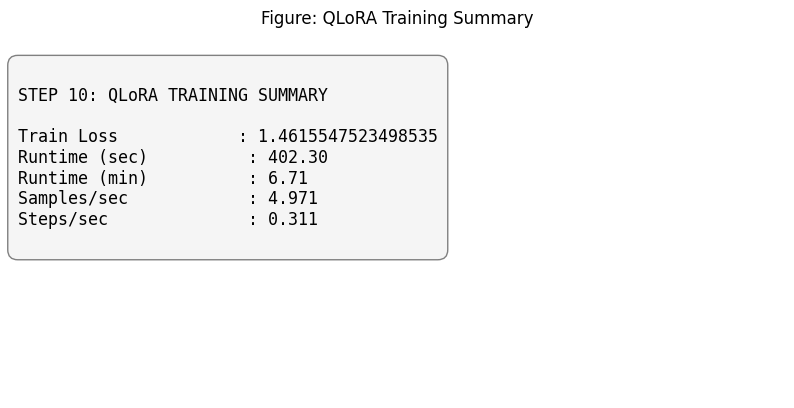

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.axis("off")

training_summary_text = f"""
STEP 10: QLoRA TRAINING SUMMARY

Train Loss            : {qlora_train_metrics.get("train_loss", "N/A")}
Runtime (sec)          : {qlora_train_metrics.get("train_runtime", train_time):.2f}
Runtime (min)          : {qlora_train_metrics.get("train_runtime", train_time)/60:.2f}
Samples/sec            : {qlora_train_metrics.get("train_samples_per_second", "N/A")}
Steps/sec              : {qlora_train_metrics.get("train_steps_per_second", "N/A")}
"""

ax.text(
    0.01, 0.96, training_summary_text,
    fontsize=12,
    va="top",
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#f5f5f5", edgecolor="gray")
)

plt.title("Figure: QLoRA Training Summary", pad=20)
plt.show()

### QLoRA Final Table

In [ ]:
print("=" * 80)
print("STEP 10: QLoRA RESULTS TABLE")
print("=" * 80)

import pandas as pd
from IPython.display import display
import math
import torch

# If qlora_results already exists, use it.
# Otherwise build it from existing QLoRA variables.
if "qlora_results" not in globals():
    qlora_results = pd.DataFrame([{
        "Method": "QLoRA",
        "Training Samples": len(qlora_trainer.train_dataset),
        "Validation Samples": len(qlora_trainer.eval_dataset),
        "Epochs": qlora_training_args.num_train_epochs,
        "Batch Size": qlora_training_args.per_device_train_batch_size,
        "Gradient Accumulation": qlora_training_args.gradient_accumulation_steps,
        "Learning Rate": qlora_training_args.learning_rate,
        "Training Loss": round(qlora_train.metrics["train_loss"], 4),
        "Validation Loss": round(qlora_evaluation["eval_loss"], 4),
        "Perplexity": round(math.exp(qlora_evaluation["eval_loss"]), 4),
        "Training Time (sec)": round(qlora_train.metrics["train_runtime"], 2),
        "Samples/sec": round(qlora_train.metrics["train_samples_per_second"], 3),
        "Steps/sec": round(qlora_train.metrics["train_steps_per_second"], 3),
        "GPU Memory Allocated (GB)": round(torch.cuda.memory_allocated()/1024**3, 2) if torch.cuda.is_available() else 0,
        "GPU Memory Reserved (GB)": round(torch.cuda.memory_reserved()/1024**3, 2) if torch.cuda.is_available() else 0,
    }])

print("QLoRA Training Summary")
display(qlora_results)

qlora_summary_view = qlora_results[[
    "Method",
    "Training Samples",
    "Validation Samples",
    "Epochs",
    "Batch Size",
    "Gradient Accumulation",
    "Learning Rate",
    "Training Loss",
    "Validation Loss",
    "Perplexity",
    "Training Time (sec)",
    "Samples/sec",
    "Steps/sec"
]]

print("\nCompact QLoRA Summary")
display(qlora_summary_view)

STEP 10: QLoRA RESULTS TABLE
QLoRA Training Summary


,Method,GPU,Training Samples,Validation Samples,Epochs,Batch Size,Gradient Accumulation,Learning Rate,Global Steps,Training Loss,...,Training Time (sec),Training Time (min),Samples/sec,Steps/sec,Total Parameters,Trainable Parameters,Trainable (%),GPU Memory Allocated (GB),GPU Memory Reserved (GB),Peak GPU Memory (GB)
0,QLoRA,Tesla T4,2000,500,1,2,8,0.0002,125,1.4665,...,466.68,7.78,4.286,0.268,"620,111,872","4,505,600",0.7266,2.55,2.85,3.79



Compact QLoRA Summary


,Method,Training Samples,Validation Samples,Epochs,Batch Size,Gradient Accumulation,Learning Rate,Training Loss,Validation Loss,Perplexity,Training Time (sec),Samples/sec,Steps/sec
0,QLoRA,2000,500,1,2,8,0.0002,1.4665,1.2172,3.3776,466.68,4.286,0.268


## QLoRA evaluation
What <br>
This step evaluates the trained QLoRA model on the validation split and computes perplexity from the evaluation loss. For language models, perplexity is commonly calculated as the exponentiated loss. <br>

Why <br>
Evaluation tells you whether the model actually learned something useful instead of just optimizing the training set. Perplexity is the standard language-modeling metric for this kind of comparison.


In [ ]:
print("=" * 80)
print("STEP 11: QLORA EVALUATION")
print("=" * 80)

qlora_eval_result = qlora_trainer.evaluate()
qlora_eval_loss = qlora_eval_result["eval_loss"]
qlora_ppl = math.exp(qlora_eval_loss)

print(f"Eval Loss    : {qlora_eval_loss:.4f}")
print(f"Perplexity   : {qlora_ppl:.4f}")

STEP 11: QLORA EVALUATION


Eval Loss    : 1.2138
Perplexity   : 3.3663


### Evaluation table
This gives the final QLoRA validation metrics in a clean table for your report.

In [ ]:
qlora_eval_table = pd.DataFrame({
    "Metric": [
        "Eval Loss",
        "Perplexity",
        "Eval Runtime (sec)",
        "Eval Samples/sec",
        "Eval Steps/sec"
    ],
    "Value": [
        round(qlora_eval_result.get("eval_loss", float("nan")), 4),
        round(qlora_ppl, 4),
        round(qlora_eval_result.get("eval_runtime", float("nan")), 2),
        round(qlora_eval_result.get("eval_samples_per_second", float("nan")), 3),
        round(qlora_eval_result.get("eval_steps_per_second", float("nan")), 3),
    ]
})

print("QLoRA Evaluation Metrics")
display(qlora_eval_table)

QLoRA Evaluation Metrics


,Metric,Value
0,Eval Loss,1.2138
1,Perplexity,3.3663
2,Eval Runtime (sec),27.8800
3,Eval Samples/sec,17.9350
4,Eval Steps/sec,4.4840


### Evaluation bar chart
This chart makes the loss and perplexity easy to present visually. The two metrics are on different scales, but both are useful for your final comparison.

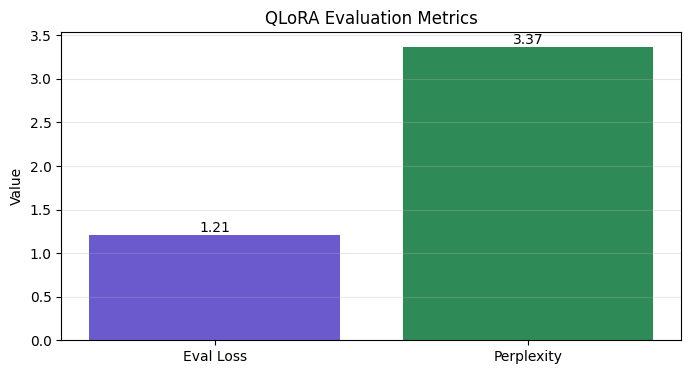

In [ ]:
plt.figure(figsize=(8, 4))
vals = [qlora_eval_loss, qlora_ppl]
labels = ["Eval Loss", "Perplexity"]
bars = plt.bar(labels, vals, color=["slateblue", "seagreen"])

plt.title("QLoRA Evaluation Metrics")
plt.ylabel("Value")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, f"{y:.2f}", ha="center", va="bottom", fontsize=10)

plt.show()

### Evaluation summary figure
This is a compact figure-style summary you can keep for the project writeup

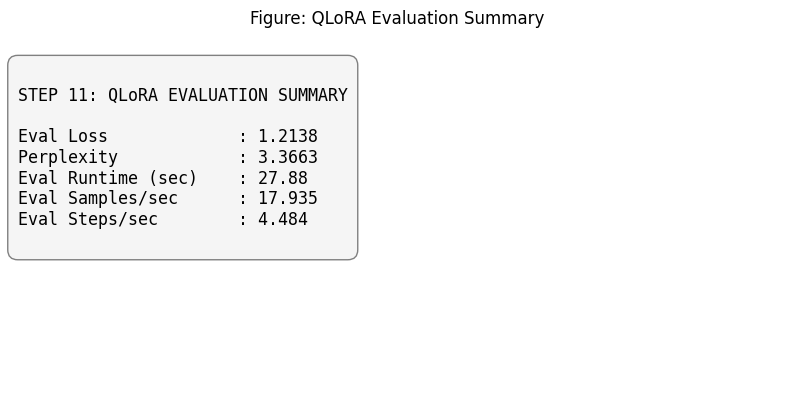

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.axis("off")

eval_summary_text = f"""
STEP 11: QLoRA EVALUATION SUMMARY

Eval Loss             : {qlora_eval_loss:.4f}
Perplexity            : {qlora_ppl:.4f}
Eval Runtime (sec)    : {qlora_eval_result.get("eval_runtime", float("nan")):.2f}
Eval Samples/sec      : {qlora_eval_result.get("eval_samples_per_second", float("nan")):.3f}
Eval Steps/sec        : {qlora_eval_result.get("eval_steps_per_second", float("nan")):.3f}
"""

ax.text(
    0.01, 0.96, eval_summary_text,
    fontsize=12,
    va="top",
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#f5f5f5", edgecolor="gray")
)

plt.title("Figure: QLoRA Evaluation Summary", pad=20)
plt.show()

### QLoRA chart

STEP 11: QLoRA RESULTS CHART


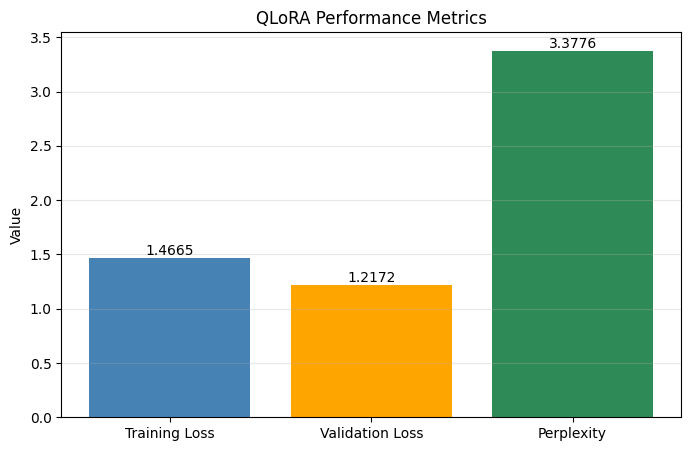

In [ ]:
print("=" * 80)
print("STEP 11: QLoRA RESULTS CHART")
print("=" * 80)

import matplotlib.pyplot as plt
import pandas as pd

qlora_chart_df = pd.DataFrame({
    "Metric": ["Training Loss", "Validation Loss", "Perplexity"],
    "Value": [
        float(qlora_results["Training Loss"].iloc[0]),
        float(qlora_results["Validation Loss"].iloc[0]),
        float(qlora_results["Perplexity"].iloc[0]),
    ]
})

plt.figure(figsize=(8, 5))
bars = plt.bar(
    qlora_chart_df["Metric"],
    qlora_chart_df["Value"],
    color=["steelblue", "orange", "seagreen"]
)

plt.title("QLoRA Performance Metrics")
plt.ylabel("Value")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.show()

### QLoRA summary figure

STEP 11: QLoRA SUMMARY FIGURE


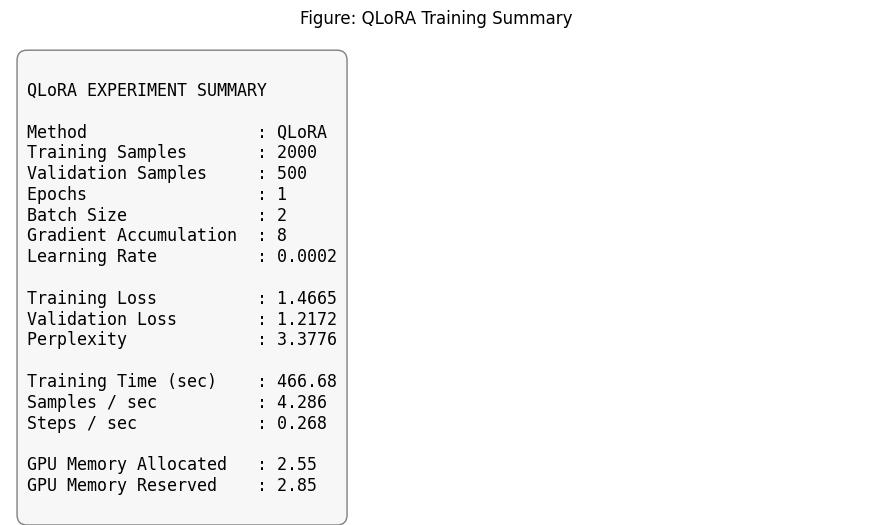

In [ ]:
print("=" * 80)
print("STEP 11: QLoRA SUMMARY FIGURE")
print("=" * 80)

import matplotlib.pyplot as plt

method = qlora_results["Method"].iloc[0]
train_samples = qlora_results["Training Samples"].iloc[0]
val_samples = qlora_results["Validation Samples"].iloc[0]
epochs = qlora_results["Epochs"].iloc[0]
batch_size = qlora_results["Batch Size"].iloc[0]
grad_accum = qlora_results["Gradient Accumulation"].iloc[0]
lr = qlora_results["Learning Rate"].iloc[0]
train_loss = qlora_results["Training Loss"].iloc[0]
val_loss = qlora_results["Validation Loss"].iloc[0]
ppl = qlora_results["Perplexity"].iloc[0]
runtime = qlora_results["Training Time (sec)"].iloc[0]
samples_sec = qlora_results["Samples/sec"].iloc[0]
steps_sec = qlora_results["Steps/sec"].iloc[0]

gpu_alloc = qlora_results["GPU Memory Allocated (GB)"].iloc[0] if "GPU Memory Allocated (GB)" in qlora_results.columns else "N/A"
gpu_res = qlora_results["GPU Memory Reserved (GB)"].iloc[0] if "GPU Memory Reserved (GB)" in qlora_results.columns else "N/A"

fig, ax = plt.subplots(figsize=(11, 6))
ax.axis("off")

figure_text = f"""
QLoRA EXPERIMENT SUMMARY

Method                 : {method}
Training Samples       : {train_samples}
Validation Samples     : {val_samples}
Epochs                 : {epochs}
Batch Size             : {batch_size}
Gradient Accumulation  : {grad_accum}
Learning Rate          : {lr}

Training Loss          : {train_loss}
Validation Loss        : {val_loss}
Perplexity             : {ppl}

Training Time (sec)    : {runtime}
Samples / sec          : {samples_sec}
Steps / sec            : {steps_sec}

GPU Memory Allocated   : {gpu_alloc}
GPU Memory Reserved    : {gpu_res}
"""

ax.text(
    0.02, 0.98, figure_text,
    fontsize=12,
    va="top",
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#f7f7f7", edgecolor="gray")
)

plt.title("Figure: QLoRA Training Summary", pad=20)
plt.show()

### QLoRA generation
This uses the fine-tuned model to generate a short TinyStories-style continuation. For decoder-only causal LMs, generation should be done with model.generate() and then decoded with the tokenizer

In [ ]:
print("=" * 80)
print("STEP 12: QLORA GENERATION")
print("=" * 80)

qlora_model.eval()

prompt = "Once upon a time, there was a little rabbit"

inputs = tokenizer(prompt, return_tensors="pt").to(qlora_model.device)

with torch.no_grad():
    output = qlora_model.generate(
        **inputs,
        max_new_tokens=100,
        temperature=0.8,
        top_p=0.95,
        do_sample=True,
        repetition_penalty=1.1,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id
    )

qlora_generated_story = tokenizer.decode(output[0], skip_special_tokens=True)

print(qlora_generated_story)

STEP 12: QLORA GENERATION
Once upon a time, there was a little rabbit who loved to run and explore. One day, the rabbit decided to go on an adventure to find some new things to play with.

The rabbit started off by running through a field full of green grass. As he ran, he saw a big tree that looked very dangerous. He quickly jumped onto the branch of the tree and started playing.

But then he heard something strange - a bee! The rabbit watched as the bee flew around him.


### QLoRA generated story figure

STEP 12: QLoRA GENERATED STORY FIGURE


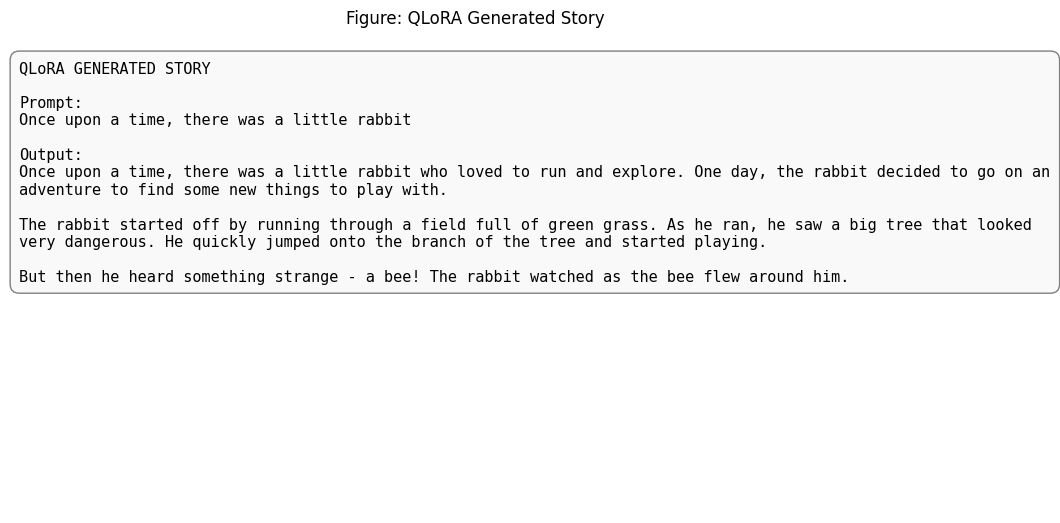

In [ ]:
print("=" * 80)
print("STEP 12: QLoRA GENERATED STORY FIGURE")
print("=" * 80)

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")

story_preview = qlora_generated_story[:900] if "qlora_generated_story" in globals() else "qlora_generated_story not found."

ax.text(
    0.01, 0.98,
    f"QLoRA GENERATED STORY\n\nPrompt:\nOnce upon a time, there was a little rabbit\n\nOutput:\n{story_preview}",
    fontsize=11,
    va="top",
    wrap=True,
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#f9f9f9", edgecolor="gray")
)

plt.title("Figure: QLoRA Generated Story", pad=20)
plt.show()

### Save QLoRA adapter
For PEFT methods, the normal approach is to save the adapter weights and config with save_pretrained(). That keeps the checkpoint small and lets you reload it later on top of the base model

In [ ]:
print("=" * 80)
print("STEP 13: SAVE QLORA ADAPTER")
print("=" * 80)

qlora_save_dir = "./qlora_adapter"

qlora_model.save_pretrained(qlora_save_dir)
tokenizer.save_pretrained(qlora_save_dir)

print(f"QLoRA adapter saved to: {qlora_save_dir}")

STEP 13: SAVE QLORA ADAPTER
QLoRA adapter saved to: ./qlora_adapter


### Step 14: Final rubric cell
This is the single comparison cell you asked for: it should run once after QLoRA is complete and compare LoRA vs QLoRA on the important project metrics

In [ ]:
def pick_var(*names):
    for name in names:
        if name in globals():
            return globals()[name]
    return None

lora_loss = pick_var("lora_eval_loss", "evaluation_loss", "eval_loss")
lora_ppl = pick_var("lora_ppl", "perplexity", "lora_perplexity")
qlora_loss = pick_var("qlora_eval_loss")
qlora_ppl_val = pick_var("qlora_ppl")

rubric = pd.DataFrame({
    "Metric": [
        "Training Method",
        "Base Model Precision",
        "Trainable Parameters",
        "GPU Memory Use",
        "Training Speed",
        "Validation Loss",
        "Perplexity",
        "Best For"
    ],
    "LoRA": [
        "LoRA",
        "Full precision / fp16 depending on setup",
        "Small adapter set",
        "Moderate",
        "Fast",
        round(lora_loss, 4) if lora_loss is not None else "N/A",
        round(lora_ppl, 4) if lora_ppl is not None else "N/A",
        "Quality-first baseline"
    ],
    "QLoRA": [
        "QLoRA",
        "4-bit quantized",
        "Small adapter set",
        "Lower",
        "Efficient under memory limits",
        round(qlora_loss, 4) if qlora_loss is not None else "N/A",
        round(qlora_ppl_val, 4) if qlora_ppl_val is not None else "N/A",
        "Best for limited GPU memory"
    ]
})

display(rubric)

,Metric,LoRA,QLoRA
0,Training Method,LoRA,QLoRA
1,Base Model Precision,Full precision / fp16 depending on setup,4-bit quantized
2,Trainable Parameters,Small adapter set,Small adapter set
3,GPU Memory Use,Moderate,Lower
4,Training Speed,Fast,Efficient under memory limits
5,Validation Loss,1.1988,1.2138
6,Perplexity,3.3162,3.3663
7,Best For,Quality-first baseline,Best for limited GPU memory


In [ ]:
import math

# Recover LoRA metrics from earlier LoRA run
if "evaluation" in globals():
    lora_eval_loss = evaluation["eval_loss"]
    lora_ppl = math.exp(lora_eval_loss)
    print(f"LoRA eval loss recovered: {lora_eval_loss:.4f}")
    print(f"LoRA perplexity recovered: {lora_ppl:.4f}")
else:
    print("LoRA evaluation object not found. Rerun the LoRA evaluation cell first.")

LoRA eval loss recovered: 1.1988
LoRA perplexity recovered: 3.3162


### final chart
If you have both LoRA and QLoRA losses available, this bar chart gives a clean visual comparison.

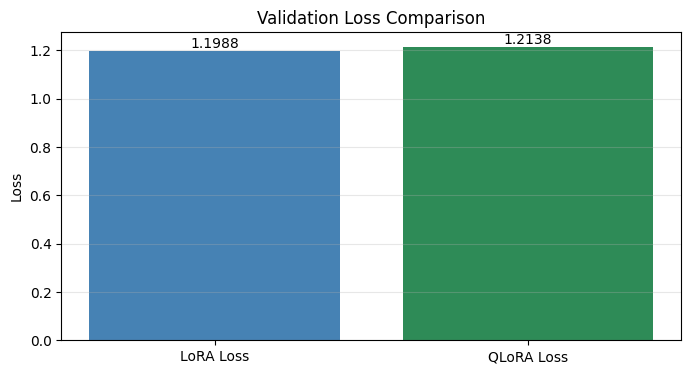

In [ ]:
if "lora_eval_loss" in globals() and "qlora_eval_loss" in globals():
    plt.figure(figsize=(8, 4))
    labels = ["LoRA Loss", "QLoRA Loss"]
    vals = [lora_eval_loss, qlora_eval_loss]
    bars = plt.bar(labels, vals, color=["steelblue", "seagreen"])
    plt.title("Validation Loss Comparison")
    plt.ylabel("Loss")
    plt.grid(axis="y", alpha=0.3)

    for bar in bars:
        y = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, y, f"{y:.4f}", ha="center", va="bottom", fontsize=10)

    plt.show()
else:
    print("Need both lora_eval_loss and qlora_eval_loss to draw the comparison chart.")

## Compare generations
The best setup is to compare:

Base model output

LoRA fine-tuned output

QLoRA fine-tuned output

using the same prompt, same generation settings, and then judge them on fluency, coherence, relevance, and story quality. Qualitative comparison is especially useful because two models can have close perplexity values but still feel different when generating actual text.

In [ ]:
print("=" * 80)
print("GENERATION COMPARISON: BASE vs LoRA vs QLoRA")
print("=" * 80)

prompt = "Once upon a time, there was a little rabbit"

gen_kwargs = {
    "max_new_tokens": 100,
    "temperature": 0.8,
    "top_p": 0.95,
    "do_sample": True,
    "repetition_penalty": 1.1,
    "pad_token_id": tokenizer.pad_token_id,
    "eos_token_id": tokenizer.eos_token_id
}

def generate_text(model, prompt):
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output = model.generate(**inputs, **gen_kwargs)
    return tokenizer.decode(output[0], skip_special_tokens=True)

base_prompt_output = None
lora_prompt_output = None
qlora_prompt_output = None

# Base model
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto"
)
base_prompt_output = generate_text(base_model, prompt)

# LoRA model
lora_prompt_output = generate_text(model, prompt)

# QLoRA model
qlora_prompt_output = generate_text(qlora_model, prompt)

print("\nBASE MODEL OUTPUT:\n")
print(base_prompt_output)

print("\n" + "=" * 80)
print("LORA MODEL OUTPUT:\n")
print(lora_prompt_output)

print("\n" + "=" * 80)
print("QLORA MODEL OUTPUT:\n")
print(qlora_prompt_output)

GENERATION COMPARISON: BASE vs LoRA vs QLoRA


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


BASE MODEL OUTPUT:

Once upon a time, there was a little rabbit named Tim. He lived in a big old house with his family, Mama Rabbit and Papa Rabbit.

One day, as they were out for a walk, Tim felt something strange move inside him. It was as if an old, familiar friend had come back to visit him. But it wasn't just any old friend – this one was different. It spoke in a language Tim didn’t know.

“Who are you?” Tim asked, scared but curious

LORA MODEL OUTPUT:

Once upon a time, there was a little rabbit. She loved to run around and explore the forest. One day, she saw something very special. It was a beautiful flower!

The little rabbit felt so happy that she wanted to capture it with her camera. So she ran through the forest until she found the perfect spot. She took a few pictures of the flowers and then put her camera away.

After taking some snaps, the little rabbit realized that there was more to life than just running around in the forest.

QLORA MODEL OUTPUT:

Once upon a time, 

## Qualitative comparison
 It compares LoRA vs QLoRA generated responses using the same prompt, same decoding settings, and a fixed seed, then shows a table, rubric, chart, and figure. Qualitative side-by-side comparison with a rubric is a good complement to loss/perplexity-based evaluation for text generation tasks.

### Single Prompt Comaparison

STEP 15: AUTOMATIC RESPONSE COMPARISON - LoRA vs QLoRA

PROMPT:

Once upon a time, there was a little rabbit

LORA OUTPUT:

Once upon a time, there was a little rabbit. He loved to play with his friends. One day, he saw an old tree in the forest and decided to climb it.

When he got to the top, he saw a beautiful flower on the branch. The flower was yellow and big! It was so pretty that the rabbit wanted to take it home with him.

But when he tried to reach the flower, he fell off the tree. He hurt his back and had to sit down. The flower stayed on the

QLORA OUTPUT:

Once upon a time, there was a little rabbit. He loved to play with his friends. One day, the rabbit wanted to do something special. He said, "Let's go for a walk!" His friends were excited too.

The rabbit and his friends walked through the forest. They saw lots of animals. The rabbit saw a bird flying high in the sky. The rabbit shouted, "I think this is my favorite animal! It's so big and white!" 

The rabbit and

Autom

,Model,Generated Text,Fluency Score,Relevance Score,Creativity Score,Coherence Score,Story Quality Score
0,LoRA,"Once upon a time, there was a little rabbit. H...",5,5,5,4,5
1,QLoRA,"Once upon a time, there was a little rabbit. H...",5,5,5,4,5



Automatic qualitative rubric


,Criterion,LoRA Score (1-5),QLoRA Score (1-5)
0,Fluency,5,5
1,Coherence,4,4
2,Relevance to Prompt,5,5
3,Creativity,5,5
4,Story Quality,5,5


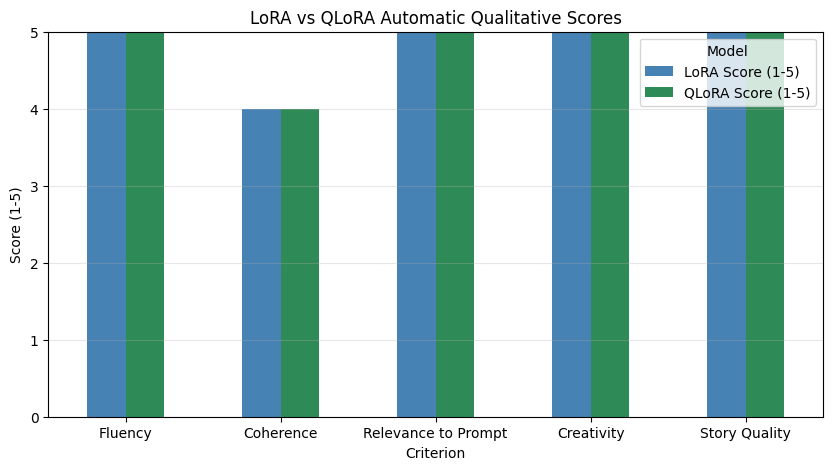

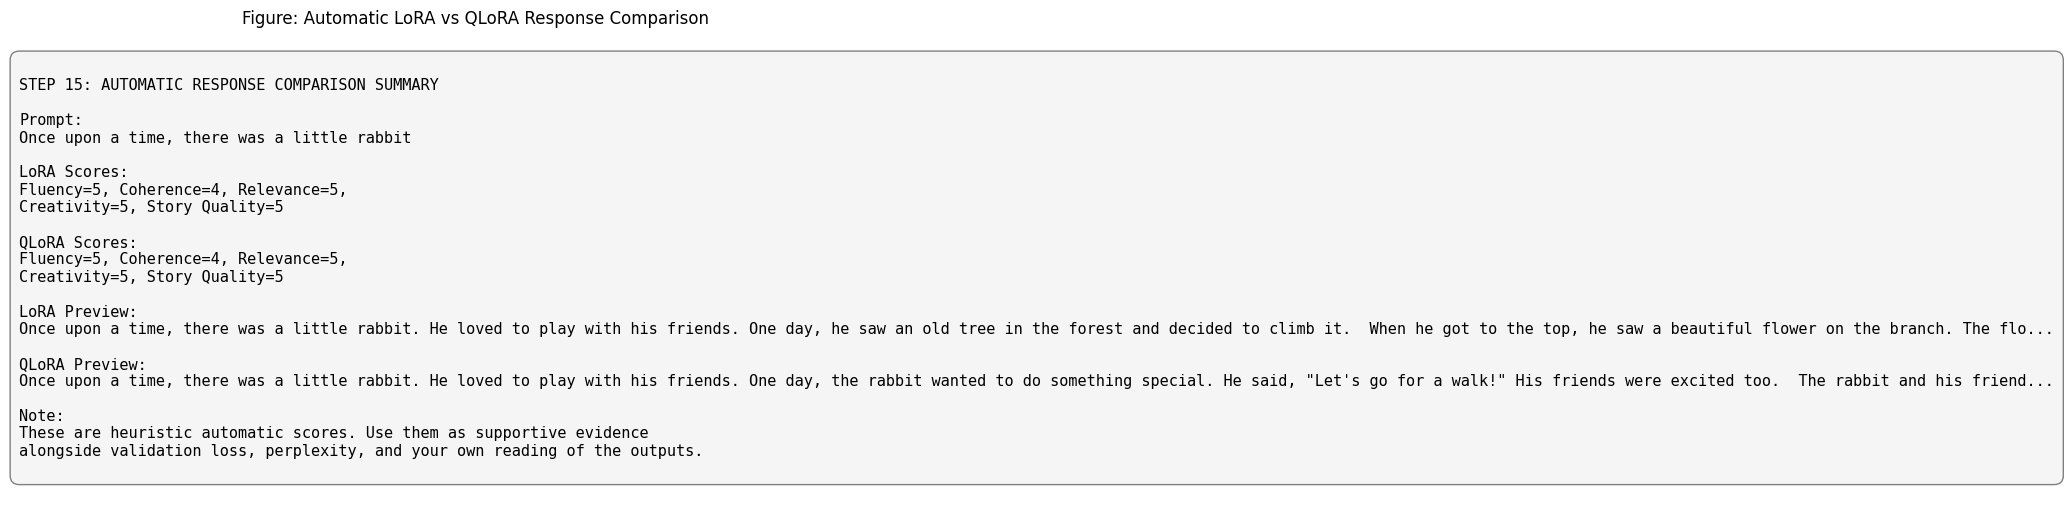

In [ ]:
print("=" * 80)
print("STEP 15: AUTOMATIC RESPONSE COMPARISON - LoRA vs QLoRA")
print("=" * 80)

import re
import math
import torch
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# -------------------------------------------------------------------
# 1. Same prompt + same generation settings
# -------------------------------------------------------------------
comparison_prompt = "Once upon a time, there was a little rabbit"

gen_kwargs = {
    "max_new_tokens": 100,
    "temperature": 0.7,
    "top_p": 0.9,
    "do_sample": True,
    "repetition_penalty": 1.1,
    "pad_token_id": tokenizer.pad_token_id,
    "eos_token_id": tokenizer.eos_token_id
}

def set_seed_everywhere(seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def generate_text(model_obj, prompt, seed=42):
    model_obj.eval()
    set_seed_everywhere(seed)
    inputs = tokenizer(prompt, return_tensors="pt").to(model_obj.device)
    with torch.no_grad():
        output = model_obj.generate(**inputs, **gen_kwargs)
    return tokenizer.decode(output[0], skip_special_tokens=True)

# -------------------------------------------------------------------
# 2. Generate outputs
# -------------------------------------------------------------------
lora_text = generate_text(model, comparison_prompt, seed=42)
qlora_text = generate_text(qlora_model, comparison_prompt, seed=42)

print("\nPROMPT:\n")
print(comparison_prompt)

print("\n" + "=" * 80)
print("LORA OUTPUT:\n")
print(lora_text)

print("\n" + "=" * 80)
print("QLORA OUTPUT:\n")
print(qlora_text)

# -------------------------------------------------------------------
# 3. Automatic heuristic scoring
# Scores are 1 to 5
# -------------------------------------------------------------------
def split_sentences(text):
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    return [s for s in sentences if s.strip()]

def tokenize_words(text):
    return re.findall(r"\b[a-zA-Z']+\b", text.lower())

def score_fluency(text):
    sentences = split_sentences(text)
    words = tokenize_words(text)
    if len(words) == 0:
        return 1

    avg_len = len(words) / max(len(sentences), 1)
    punctuation_bonus = 1 if any(p in text for p in ".!?") else 0
    long_enough_bonus = 1 if len(words) >= 50 else 0
    balanced_len_bonus = 1 if 6 <= avg_len <= 18 else 0
    score = 2 + punctuation_bonus + long_enough_bonus + balanced_len_bonus
    return max(1, min(5, score))

def score_relevance(text, prompt):
    prompt_words = set(tokenize_words(prompt))
    text_words = set(tokenize_words(text))
    overlap = len(prompt_words.intersection(text_words))

    rabbit_bonus = 1 if "rabbit" in text_words else 0
    story_bonus = 1 if any(w in text_words for w in ["once", "little", "named", "one", "day"]) else 0
    overlap_bonus = 1 if overlap >= 3 else 0

    score = 2 + rabbit_bonus + story_bonus + overlap_bonus
    return max(1, min(5, score))

def score_creativity(text):
    words = tokenize_words(text)
    unique_ratio = len(set(words)) / max(len(words), 1)

    descriptive_words = [
        "beautiful", "special", "adventure", "forest", "river", "happy",
        "curious", "strange", "exciting", "wonderful", "magic", "flower"
    ]
    desc_count = sum(1 for w in words if w in descriptive_words)

    unique_bonus = 1 if unique_ratio > 0.55 else 0
    desc_bonus = 1 if desc_count >= 2 else 0
    length_bonus = 1 if len(words) >= 60 else 0

    score = 2 + unique_bonus + desc_bonus + length_bonus
    return max(1, min(5, score))

def score_coherence(text):
    sentences = split_sentences(text)
    transition_words = ["one day", "then", "after", "so", "because", "when", "but"]
    transitions = sum(1 for t in transition_words if t in text.lower())

    sentence_bonus = 1 if len(sentences) >= 3 else 0
    transition_bonus = 1 if transitions >= 1 else 0
    completion_bonus = 1 if text.strip()[-1] in ".!?" else 0

    score = 2 + sentence_bonus + transition_bonus + completion_bonus
    return max(1, min(5, score))

def score_story_quality(text, prompt):
    f = score_fluency(text)
    r = score_relevance(text, prompt)
    c = score_creativity(text)
    h = score_coherence(text)
    return round((f + r + c + h) / 4)

# LoRA scores
lora_fluency = score_fluency(lora_text)
lora_relevance = score_relevance(lora_text, comparison_prompt)
lora_creativity = score_creativity(lora_text)
lora_coherence = score_coherence(lora_text)
lora_story_quality = score_story_quality(lora_text, comparison_prompt)

# QLoRA scores
qlora_fluency = score_fluency(qlora_text)
qlora_relevance = score_relevance(qlora_text, comparison_prompt)
qlora_creativity = score_creativity(qlora_text)
qlora_coherence = score_coherence(qlora_text)
qlora_story_quality = score_story_quality(qlora_text, comparison_prompt)

# -------------------------------------------------------------------
# 4. Comparison table with automatic scores
# -------------------------------------------------------------------
comparison_df = pd.DataFrame({
    "Model": ["LoRA", "QLoRA"],
    "Generated Text": [lora_text, qlora_text],
    "Fluency Score": [lora_fluency, qlora_fluency],
    "Relevance Score": [lora_relevance, qlora_relevance],
    "Creativity Score": [lora_creativity, qlora_creativity],
    "Coherence Score": [lora_coherence, qlora_coherence],
    "Story Quality Score": [lora_story_quality, qlora_story_quality]
})

print("\nAutomatic qualitative comparison table")
display(comparison_df)

# -------------------------------------------------------------------
# 5. Rubric table
# -------------------------------------------------------------------
rubric_df = pd.DataFrame({
    "Criterion": [
        "Fluency",
        "Coherence",
        "Relevance to Prompt",
        "Creativity",
        "Story Quality"
    ],
    "LoRA Score (1-5)": [
        lora_fluency,
        lora_coherence,
        lora_relevance,
        lora_creativity,
        lora_story_quality
    ],
    "QLoRA Score (1-5)": [
        qlora_fluency,
        qlora_coherence,
        qlora_relevance,
        qlora_creativity,
        qlora_story_quality
    ]
})

print("\nAutomatic qualitative rubric")
display(rubric_df)

# -------------------------------------------------------------------
# 6. Score chart
# -------------------------------------------------------------------
score_plot_df = rubric_df.set_index("Criterion")

ax = score_plot_df.plot(
    kind="bar",
    figsize=(10, 5),
    color=["steelblue", "seagreen"]
)

plt.title("LoRA vs QLoRA Automatic Qualitative Scores")
plt.ylabel("Score (1-5)")
plt.xlabel("Criterion")
plt.ylim(0, 5)
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.show()

# -------------------------------------------------------------------
# 7. Figure-style summary
# -------------------------------------------------------------------
lora_preview = lora_text[:220].replace("\n", " ")
qlora_preview = qlora_text[:220].replace("\n", " ")

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")

summary_text = f"""
STEP 15: AUTOMATIC RESPONSE COMPARISON SUMMARY

Prompt:
{comparison_prompt}

LoRA Scores:
Fluency={lora_fluency}, Coherence={lora_coherence}, Relevance={lora_relevance},
Creativity={lora_creativity}, Story Quality={lora_story_quality}

QLoRA Scores:
Fluency={qlora_fluency}, Coherence={qlora_coherence}, Relevance={qlora_relevance},
Creativity={qlora_creativity}, Story Quality={qlora_story_quality}

LoRA Preview:
{lora_preview}...

QLoRA Preview:
{qlora_preview}...

Note:
These are heuristic automatic scores. Use them as supportive evidence
alongside validation loss, perplexity, and your own reading of the outputs.
"""

ax.text(
    0.01, 0.98, summary_text,
    fontsize=11,
    va="top",
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#f5f5f5", edgecolor="gray")
)

plt.title("Figure: Automatic LoRA vs QLoRA Response Comparison", pad=20)
plt.show()

### Multi-prompt qualitative comparison
upgraded the qualitative evaluation by using three prompts, longer generations, and stricter automatic rubric scoring. This gives a more stable comparison of LoRA and QLoRA output quality.

STEP 15: MULTI-PROMPT QUALITATIVE COMPARISON - LoRA vs QLoRA

Generated outputs and automatic scores


,Prompt No.,Prompt,LoRA Text,QLoRA Text,LoRA Fluency,LoRA Coherence,LoRA Relevance,LoRA Creativity,LoRA Story Quality,QLoRA Fluency,QLoRA Coherence,QLoRA Relevance,QLoRA Creativity,QLoRA Story Quality
0,1,"Once upon a time, there was a little rabbit","Once upon a time, there was a little rabbit na...","Once upon a time, there was a little rabbit na...",5,4,5,4,4.50,5,4,5,5,4.75
1,2,A small girl found a glowing key in the garden,A small girl found a glowing key in the garden...,A small girl found a glowing key in the garden...,5,5,5,5,5.00,5,4,5,4,4.50
2,3,The young boy looked at the dark cloud and fel...,The young boy looked at the dark cloud and fel...,The young boy looked at the dark cloud and fel...,5,5,5,4,4.75,5,5,5,4,4.75



Average qualitative scores across 3 prompts


,Criterion,LoRA Avg Score,QLoRA Avg Score
0,Fluency,5.000000,5.000000
1,Coherence,4.666667,4.333333
2,Relevance,5.000000,5.000000
3,Creativity,4.333333,4.333333
4,Story Quality,4.750000,4.666667


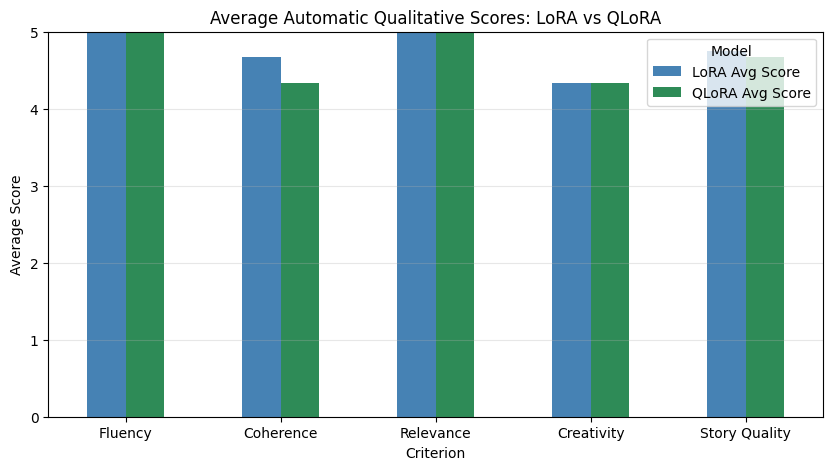

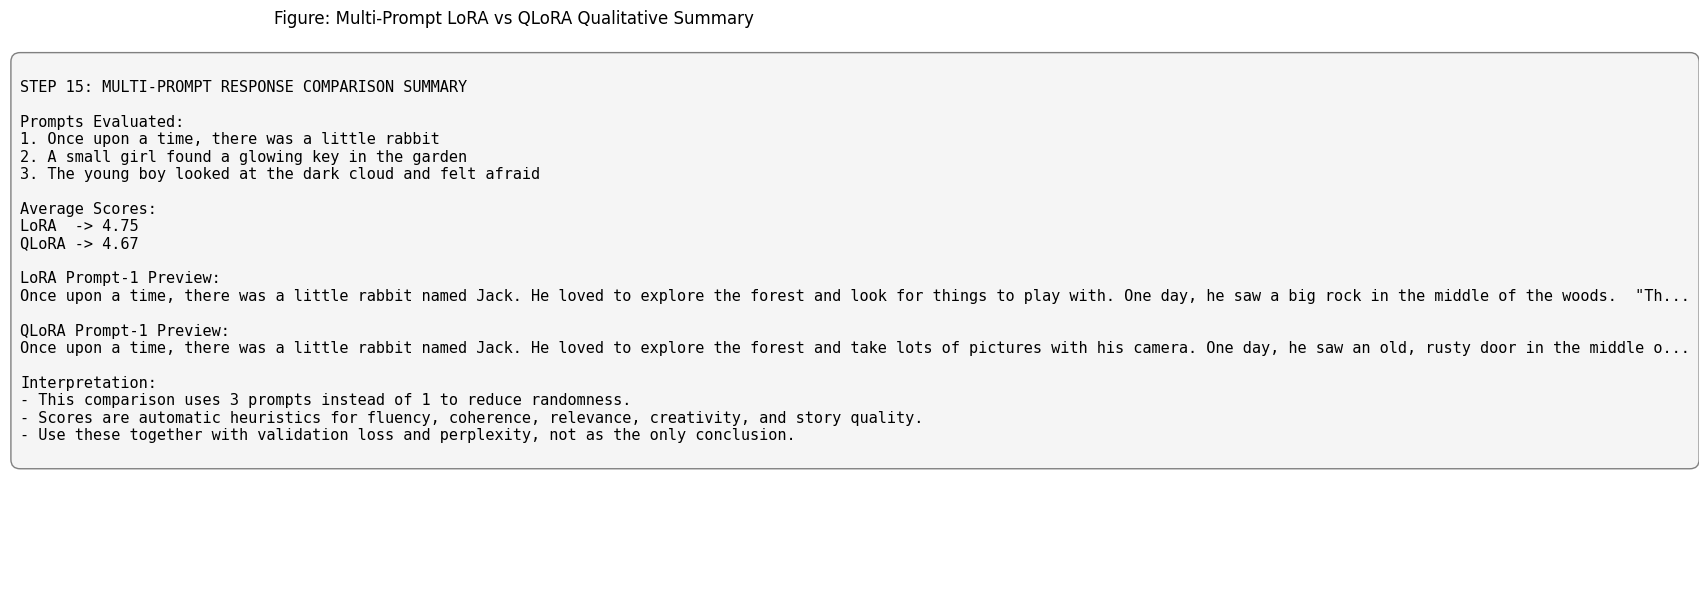

In [ ]:
print("=" * 90)
print("STEP 15: MULTI-PROMPT QUALITATIVE COMPARISON - LoRA vs QLoRA")
print("=" * 90)

import re
import math
import torch
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# -------------------------------------------------------------------
# 1. Prompts + longer generation settings
# -------------------------------------------------------------------
comparison_prompts = [
    "Once upon a time, there was a little rabbit",
    "A small girl found a glowing key in the garden",
    "The young boy looked at the dark cloud and felt afraid"
]

gen_kwargs = {
    "max_new_tokens": 150,
    "temperature": 0.7,
    "top_p": 0.9,
    "do_sample": True,
    "repetition_penalty": 1.15,
    "pad_token_id": tokenizer.pad_token_id,
    "eos_token_id": tokenizer.eos_token_id
}

def set_seed_everywhere(seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def generate_text(model_obj, prompt, seed=42):
    model_obj.eval()
    set_seed_everywhere(seed)
    inputs = tokenizer(prompt, return_tensors="pt").to(model_obj.device)
    with torch.no_grad():
        output = model_obj.generate(**inputs, **gen_kwargs)
    return tokenizer.decode(output[0], skip_special_tokens=True)

# -------------------------------------------------------------------
# 2. Stricter automatic scoring
# -------------------------------------------------------------------
def split_sentences(text):
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    return [s.strip() for s in sentences if s.strip()]

def tokenize_words(text):
    return re.findall(r"\b[a-zA-Z']+\b", text.lower())

def clamp_score(x):
    return max(1, min(5, int(round(x))))

def score_fluency(text):
    words = tokenize_words(text)
    sentences = split_sentences(text)
    if not words:
        return 1

    avg_sentence_len = len(words) / max(len(sentences), 1)
    punctuation_score = 1 if text.count(".") + text.count("!") + text.count("?") >= 3 else 0
    length_score = 1 if len(words) >= 80 else 0
    balanced_score = 1 if 7 <= avg_sentence_len <= 18 else 0

    raw = 2 + punctuation_score + length_score + balanced_score
    return clamp_score(raw)

def score_relevance(text, prompt):
    prompt_words = set(tokenize_words(prompt))
    text_words = set(tokenize_words(text))

    overlap = len(prompt_words.intersection(text_words))
    overlap_score = 2 if overlap >= 4 else (1 if overlap >= 2 else 0)

    first_prompt_word = tokenize_words(prompt)[-1] if tokenize_words(prompt) else ""
    keyword_score = 1 if first_prompt_word and first_prompt_word in text_words else 0

    raw = 2 + overlap_score + keyword_score
    return clamp_score(raw)

def score_creativity(text):
    words = tokenize_words(text)
    if not words:
        return 1

    unique_ratio = len(set(words)) / len(words)

    descriptive_words = {
        "beautiful", "glowing", "golden", "strange", "mysterious", "adventure",
        "whisper", "magic", "forest", "shadow", "sparkling", "wonderful",
        "suddenly", "carefully", "softly", "bravely", "curious", "exciting"
    }

    desc_count = sum(1 for w in words if w in descriptive_words)
    unique_score = 1 if unique_ratio >= 0.58 else 0
    desc_score = 1 if desc_count >= 3 else 0
    length_score = 1 if len(words) >= 90 else 0

    raw = 2 + unique_score + desc_score + length_score
    return clamp_score(raw)

def score_coherence(text):
    sentences = split_sentences(text)
    if not sentences:
        return 1

    transition_markers = [
        "one day", "then", "after that", "suddenly", "so", "because",
        "but", "when", "finally", "at last"
    ]

    transitions = sum(1 for t in transition_markers if t in text.lower())
    sentence_score = 1 if len(sentences) >= 4 else 0
    transition_score = 1 if transitions >= 2 else 0
    ending_score = 1 if text.strip()[-1] in ".!?" else 0

    raw = 2 + sentence_score + transition_score + ending_score
    return clamp_score(raw)

def score_story_quality(text, prompt):
    f = score_fluency(text)
    r = score_relevance(text, prompt)
    c = score_creativity(text)
    h = score_coherence(text)
    return round((f + r + c + h) / 4, 2)

# -------------------------------------------------------------------
# 3. Generate + score outputs for each prompt
# -------------------------------------------------------------------
rows = []

for i, prompt in enumerate(comparison_prompts, start=1):
    lora_text = generate_text(model, prompt, seed=42 + i)
    qlora_text = generate_text(qlora_model, prompt, seed=42 + i)

    lora_scores = {
        "Fluency": score_fluency(lora_text),
        "Coherence": score_coherence(lora_text),
        "Relevance": score_relevance(lora_text, prompt),
        "Creativity": score_creativity(lora_text),
        "Story Quality": score_story_quality(lora_text, prompt)
    }

    qlora_scores = {
        "Fluency": score_fluency(qlora_text),
        "Coherence": score_coherence(qlora_text),
        "Relevance": score_relevance(qlora_text, prompt),
        "Creativity": score_creativity(qlora_text),
        "Story Quality": score_story_quality(qlora_text, prompt)
    }

    rows.append({
        "Prompt No.": i,
        "Prompt": prompt,
        "LoRA Text": lora_text,
        "QLoRA Text": qlora_text,
        "LoRA Fluency": lora_scores["Fluency"],
        "LoRA Coherence": lora_scores["Coherence"],
        "LoRA Relevance": lora_scores["Relevance"],
        "LoRA Creativity": lora_scores["Creativity"],
        "LoRA Story Quality": lora_scores["Story Quality"],
        "QLoRA Fluency": qlora_scores["Fluency"],
        "QLoRA Coherence": qlora_scores["Coherence"],
        "QLoRA Relevance": qlora_scores["Relevance"],
        "QLoRA Creativity": qlora_scores["Creativity"],
        "QLoRA Story Quality": qlora_scores["Story Quality"],
    })

results_df = pd.DataFrame(rows)

# -------------------------------------------------------------------
# 4. Main comparison table
# -------------------------------------------------------------------
print("\nGenerated outputs and automatic scores")
display(results_df)

# -------------------------------------------------------------------
# 5. Average score table
# -------------------------------------------------------------------
avg_scores = pd.DataFrame({
    "Criterion": ["Fluency", "Coherence", "Relevance", "Creativity", "Story Quality"],
    "LoRA Avg Score": [
        results_df["LoRA Fluency"].mean(),
        results_df["LoRA Coherence"].mean(),
        results_df["LoRA Relevance"].mean(),
        results_df["LoRA Creativity"].mean(),
        results_df["LoRA Story Quality"].mean(),
    ],
    "QLoRA Avg Score": [
        results_df["QLoRA Fluency"].mean(),
        results_df["QLoRA Coherence"].mean(),
        results_df["QLoRA Relevance"].mean(),
        results_df["QLoRA Creativity"].mean(),
        results_df["QLoRA Story Quality"].mean(),
    ]
})

print("\nAverage qualitative scores across 3 prompts")
display(avg_scores)

# -------------------------------------------------------------------
# 6. Chart
# -------------------------------------------------------------------
plot_df = avg_scores.set_index("Criterion")

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 5),
    color=["steelblue", "seagreen"]
)

plt.title("Average Automatic Qualitative Scores: LoRA vs QLoRA")
plt.ylabel("Average Score")
plt.xlabel("Criterion")
plt.ylim(0, 5)
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.show()

# -------------------------------------------------------------------
# 7. Figure-style summary
# -------------------------------------------------------------------
lora_overall = round(avg_scores["LoRA Avg Score"].mean(), 2)
qlora_overall = round(avg_scores["QLoRA Avg Score"].mean(), 2)

prompt1_lora_preview = results_df.loc[0, "LoRA Text"][:180].replace("\n", " ")
prompt1_qlora_preview = results_df.loc[0, "QLoRA Text"][:180].replace("\n", " ")

fig, ax = plt.subplots(figsize=(13, 7))
ax.axis("off")

summary_text = f"""
STEP 15: MULTI-PROMPT RESPONSE COMPARISON SUMMARY

Prompts Evaluated:
1. {comparison_prompts[0]}
2. {comparison_prompts[1]}
3. {comparison_prompts[2]}

Average Scores:
LoRA  -> {lora_overall}
QLoRA -> {qlora_overall}

LoRA Prompt-1 Preview:
{prompt1_lora_preview}...

QLoRA Prompt-1 Preview:
{prompt1_qlora_preview}...

Interpretation:
- This comparison uses 3 prompts instead of 1 to reduce randomness.
- Scores are automatic heuristics for fluency, coherence, relevance, creativity, and story quality.
- Use these together with validation loss and perplexity, not as the only conclusion.
"""

ax.text(
    0.01, 0.98, summary_text,
    fontsize=11,
    va="top",
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#f5f5f5", edgecolor="gray")
)

plt.title("Figure: Multi-Prompt LoRA vs QLoRA Qualitative Summary", pad=20)
plt.show()